In [2]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_excel("FinalTableDatabase1.xlsx")

In [5]:
df_general

,Material,Temperature,Orientation,Time lapse,Deformation,Tension
0,38-0669-03,850,111,0.000000,0.000,715.4
1,38-0669-03,850,111,0.000000,0.000,715.4
2,38-0669-03,850,111,0.000000,0.000,715.4
3,38-0669-03,850,111,0.000000,0.000,715.4
4,38-0669-03,850,111,0.000000,0.000,715.4
...,...,...,...,...,...,...
242762,38-1486-03,950,111,240.007227,12.393,400.0
242763,38-1486-03,950,111,240.023893,12.395,400.0
242764,38-1486-03,950,111,240.040560,12.403,400.0
242765,38-1486-03,950,111,240.057227,12.408,400.0


In [11]:
def count_d2_e(array_values_e, array_values_t):
    
    array_values_d2f = []
    
    for i in range(1, len(array_values_e)):
        
        mkr_value = array_values_e[i-1] - 2*array_values_e[i] + array_values_e[i+1]
        mean_t = ((array_values_t[i-1] + array_values_t[i] + array_values_t[i+1]) / 3)**2
        
        value_d2f = mkr_value / mean_t
        
        array_values_d2f.append(value_d2f)
        
    return array_values_d2f
        
        
    

In [14]:
for material_name in df_general["Material"].unique():
    
    selected_data_time = np.array(df_general[df_general["Material"] == material_name][["Time lapse"]])
    selected_data_deformation = np.array(df_general[df_general["Material"] == material_name][["Deformation"]])
    
    print(material_name)
    print("--------------")
    print(selected_data_time)
    print("--------------")
    print(selected_data_deformation)
    print("--------------")

    
    array_values_d2f = count_d2_e(selected_data_deformation, selected_data_time)
    
    

38-0669-03
--------------
[[ 0.      ]
 [ 0.      ]
 [ 0.      ]
 ...
 [14.516163]
 [14.532847]
 [14.549531]]
--------------
[[ 0.   ]
 [ 0.   ]
 [ 0.   ]
 ...
 [13.356]
 [13.374]
 [13.357]]
--------------


C:\Users\KNS\AppData\Local\Temp\ipykernel_20872\3058641286.py:10: RuntimeWarning: invalid value encountered in divide
  value_d2f = mkr_value / mean_t


IndexError: index 1131 is out of bounds for axis 0 with size 1131

In [22]:
def calculate_second_derivative(group):
    second_derivatives = []
    for i in range(1, len(group) - 1):  # Пропускаем первый и последний элементы
        deformation_diff = (
            group["Deformation"].iloc[i - 1] 
            - 2 * group["Deformation"].iloc[i] 
            + group["Deformation"].iloc[i + 1]
        )
        time_avg = (
            group["Time lapse"].iloc[i - 1] 
            + group["Time lapse"].iloc[i] 
            + group["Time lapse"].iloc[i + 1]
        ) / 3
        if time_avg != 0:  # Избегаем деления на ноль
            second_derivative = deformation_diff / time_avg
        else:
            second_derivative = None  # Если time_avg = 0, записываем None
        second_derivatives.append(second_derivative)
    return second_derivatives

# Применение функции к каждому материалу и сохранение результатов
results = []
for material, group in df.groupby("Material"):
    second_derivatives = calculate_second_derivative(group)
    for i, derivative in enumerate(second_derivatives, start=1):  # Индексы начинаются с 1
        results.append({
            "Material": material,
            "Row Index": group.index[i],  # Сохраняем индекс строки из исходного DataFrame
            "Second Derivative": derivative
        })

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Запись результатов в CSV-файл
output_file = "second_derivatives.csv"
results_df.to_csv(output_file, index=False)

print(f"Результаты сохранены в файл: {output_file}")

Результаты сохранены в файл: second_derivatives.csv


Results saved to file: second_derivatives.csv


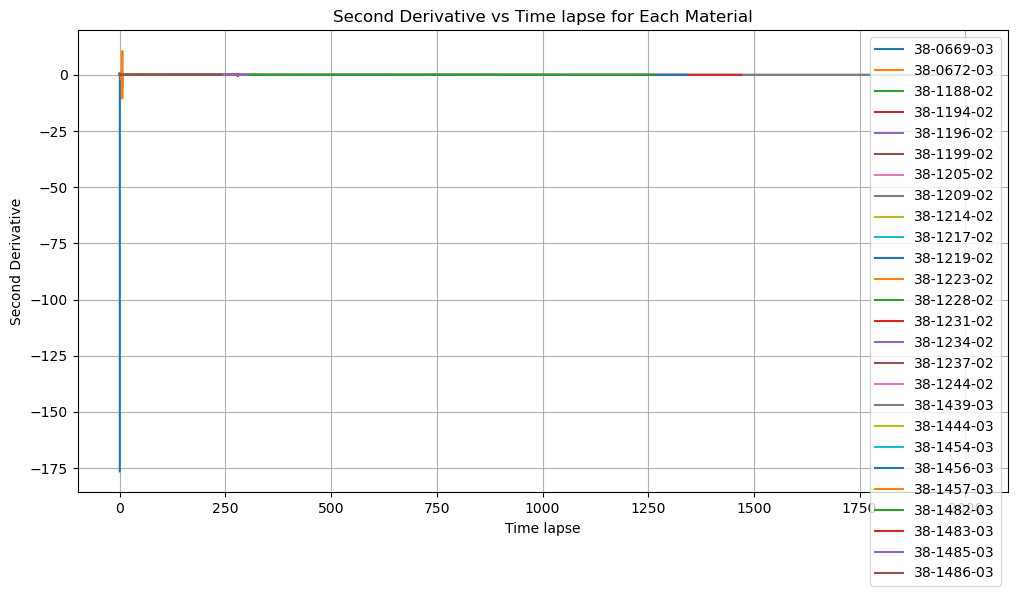

In [23]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Calculate second derivatives and store results with "Time lapse" values
results = []
for material, group in df.groupby("Material"):
    second_derivatives = calculate_second_derivative(group)
    for i, derivative in enumerate(second_derivatives, start=1):  # Indices start from 1
        time_lapse_value = group["Time lapse"].iloc[i]  # Get the corresponding "Time lapse" value
        results.append({
            "Material": material,
            "Time lapse": time_lapse_value,
            "Second Derivative": derivative
        })

# Create DataFrame from results
results_df = pd.DataFrame(results)

# Save results to CSV file
output_file = "second_derivatives.csv"
results_df.to_csv(output_file, index=False)

print(f"Results saved to file: {output_file}")

# Plot second derivative for each material over time

for material, group in results_df.groupby("Material"):
    plt.figure(figsize=(12, 6))
    plt.plot(group["Time lapse"], group["Second Derivative"], label=material)

    plt.xlabel("Time lapse")
    plt.ylabel("Second Derivative")
    plt.title("Second Derivative vs Time lapse for Each Material")
    plt.legend()
    plt.grid(True)
    plt.show()

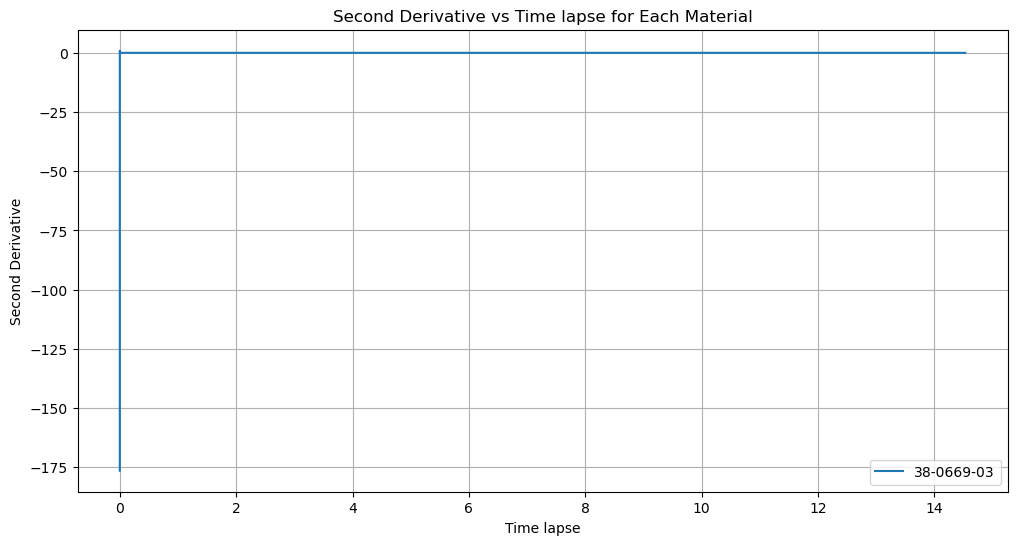

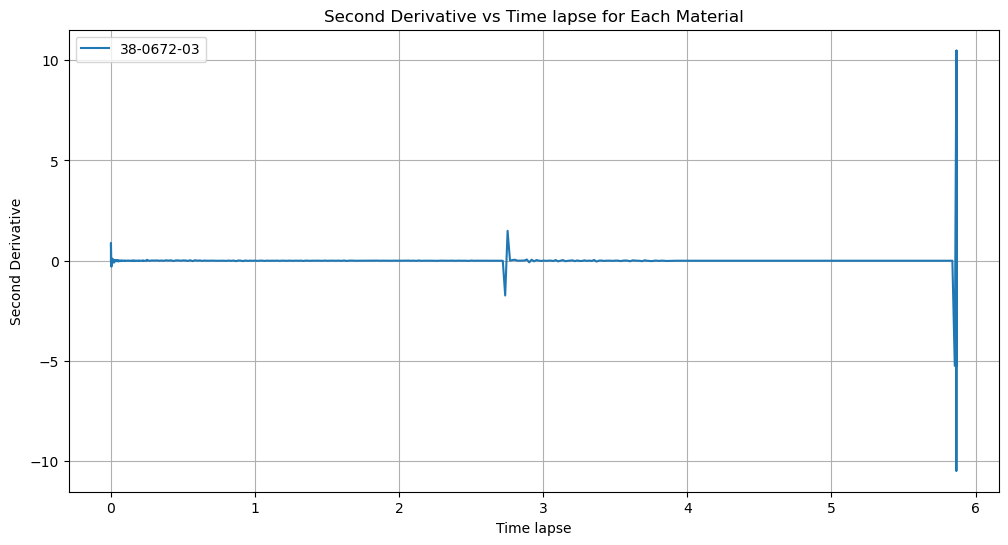

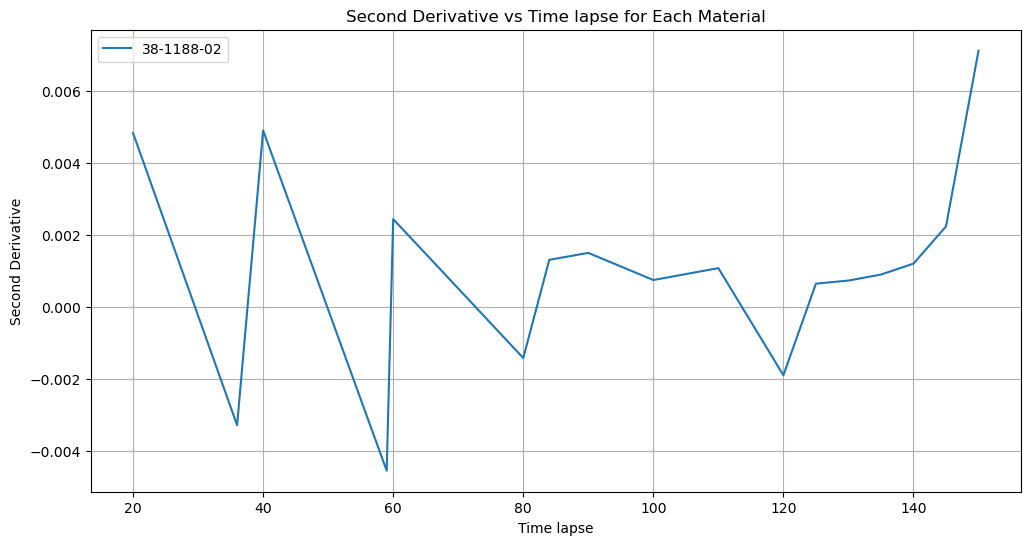

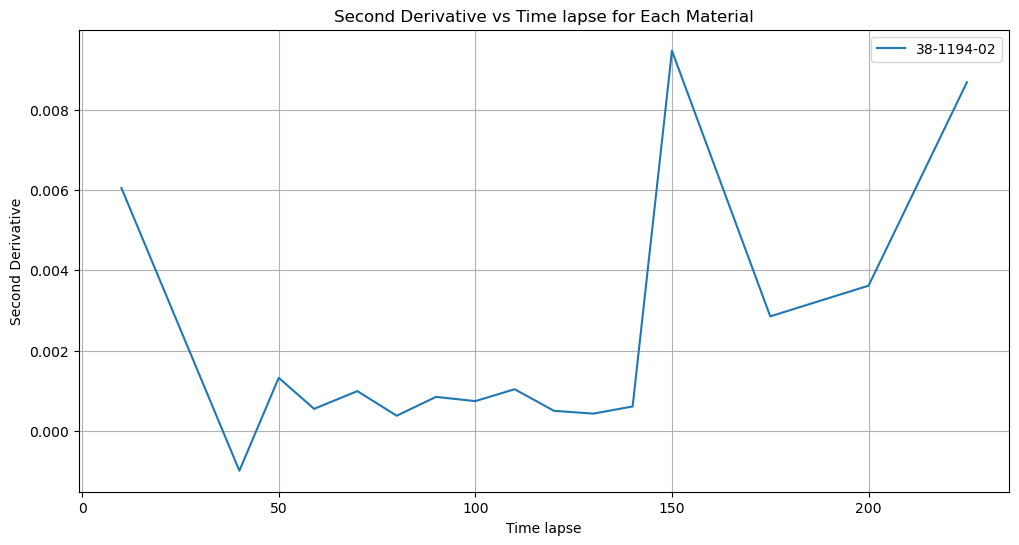

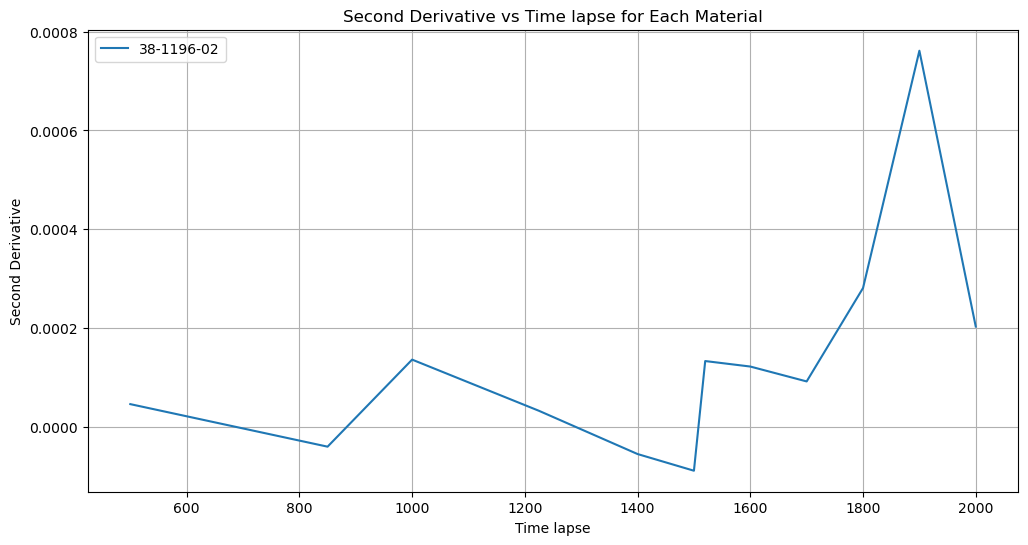

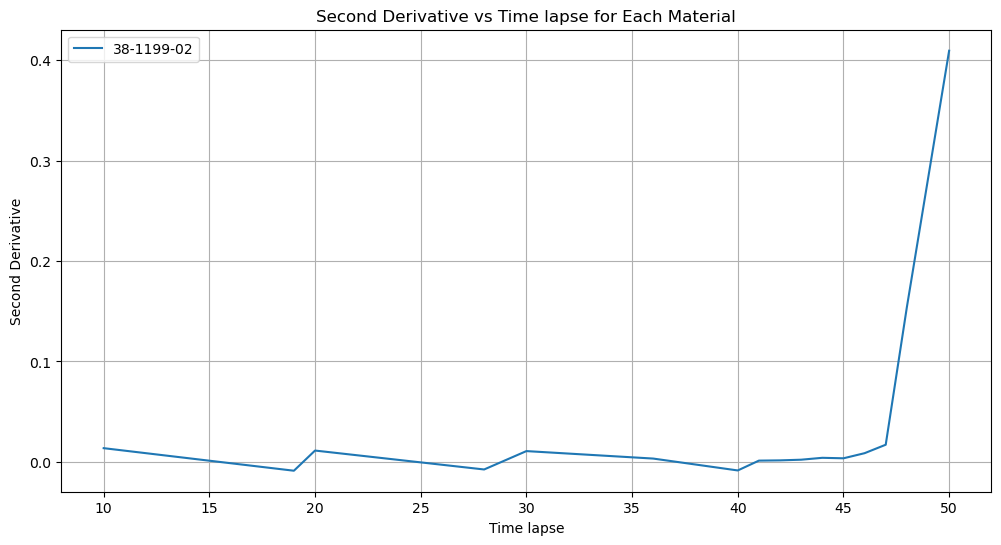

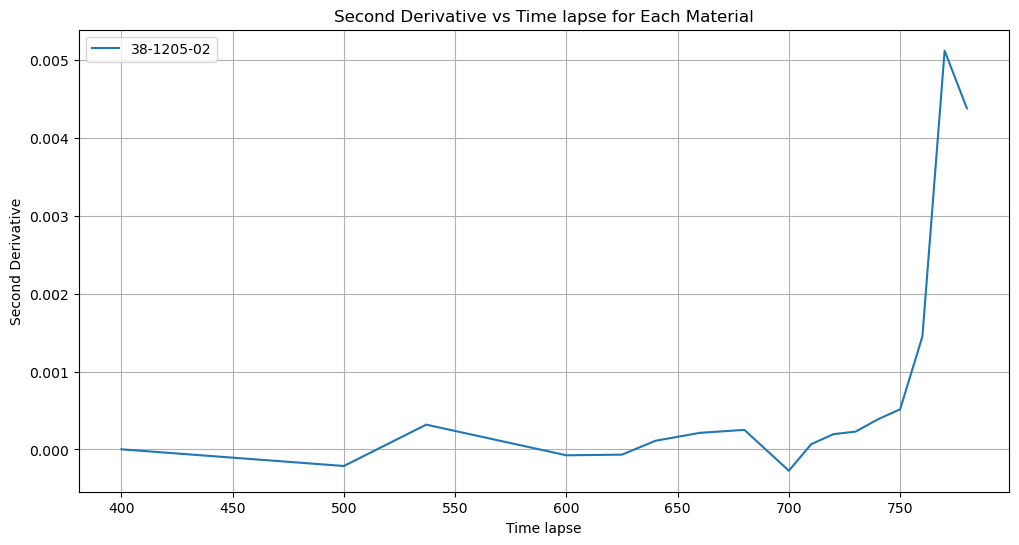

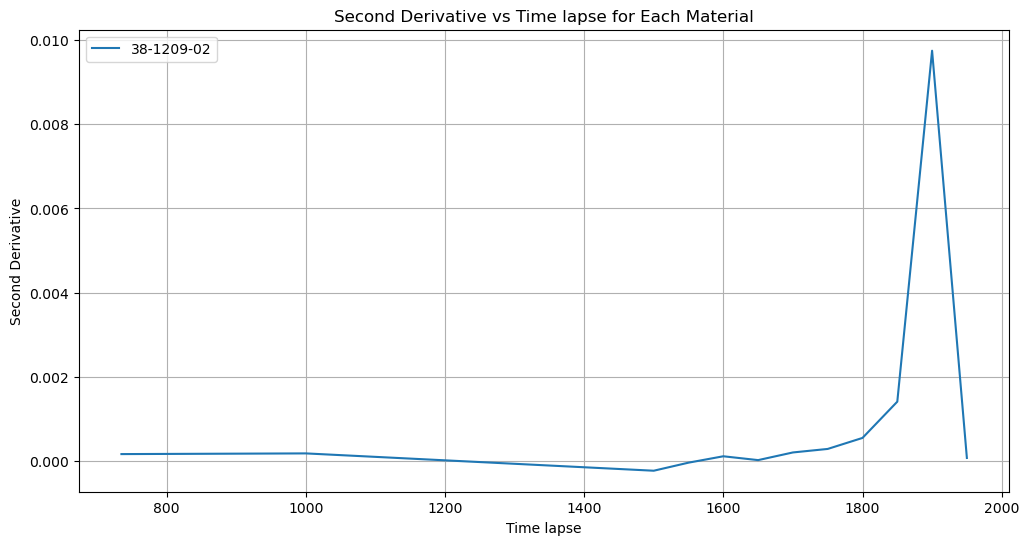

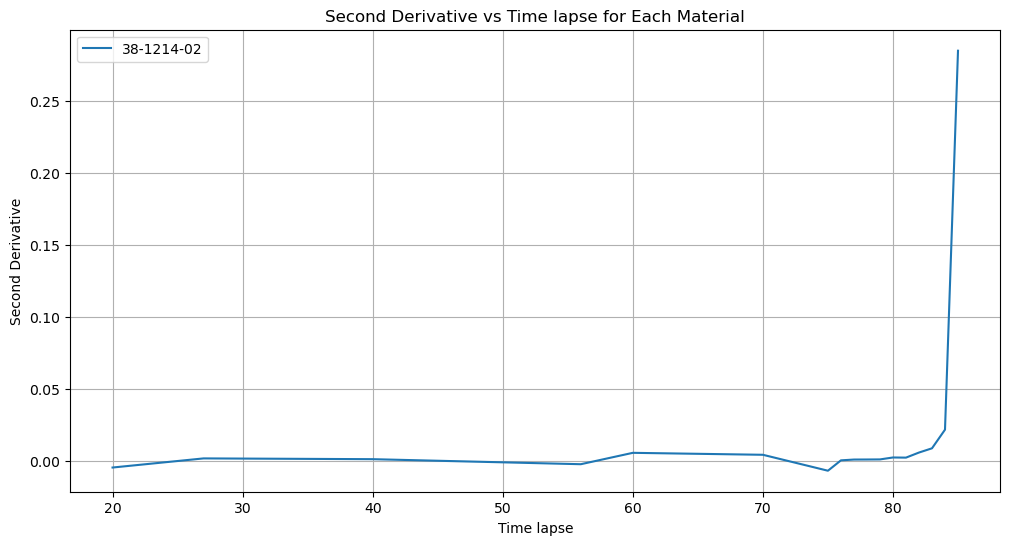

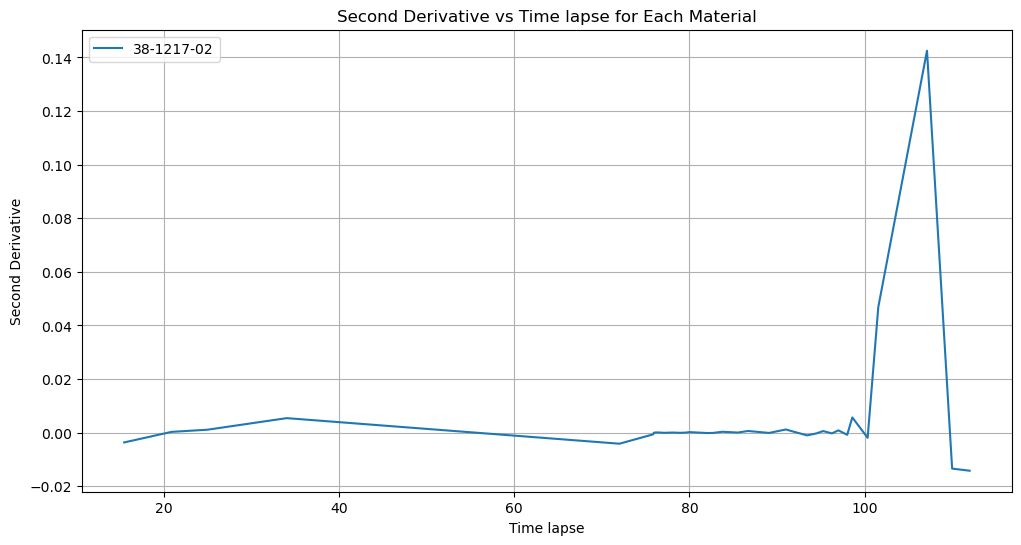

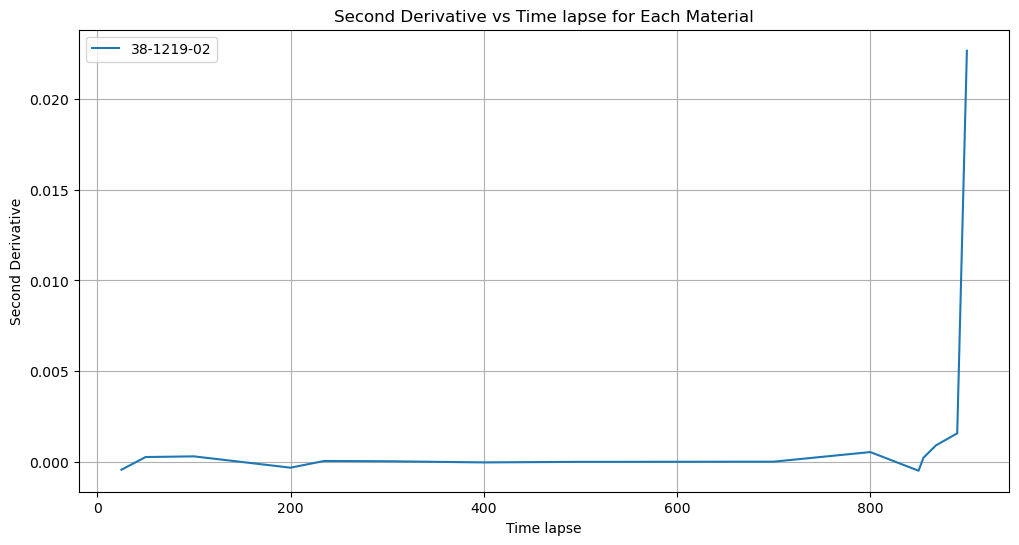

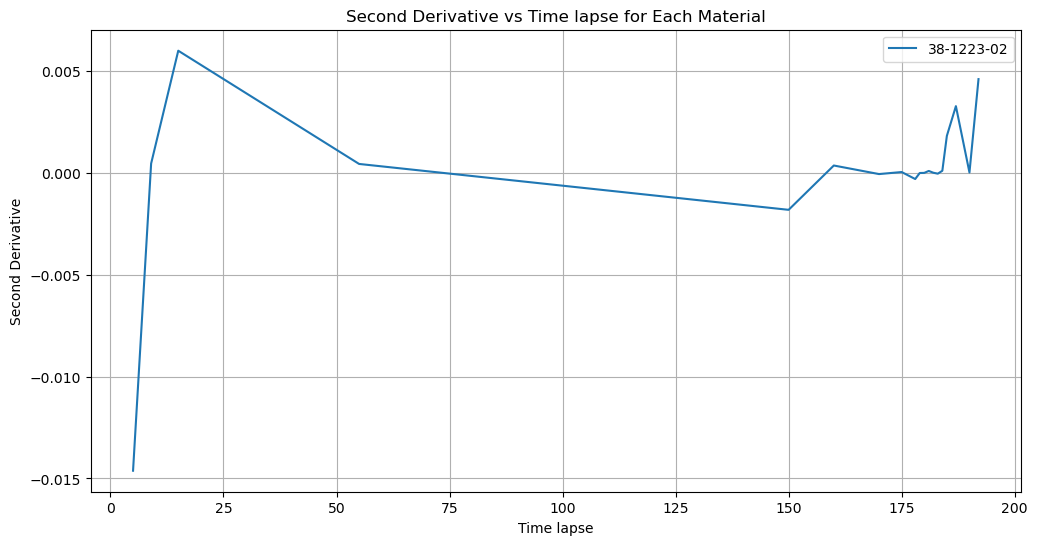

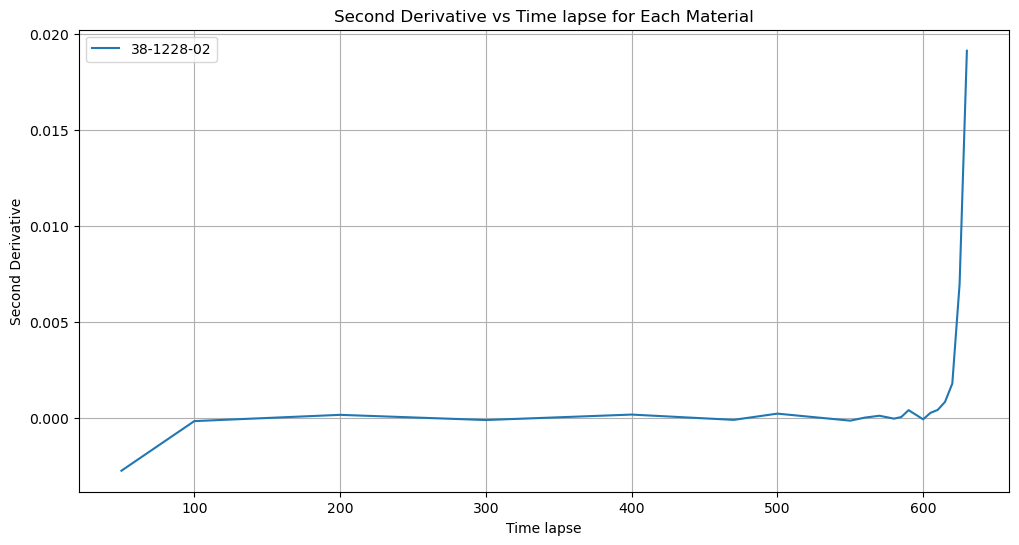

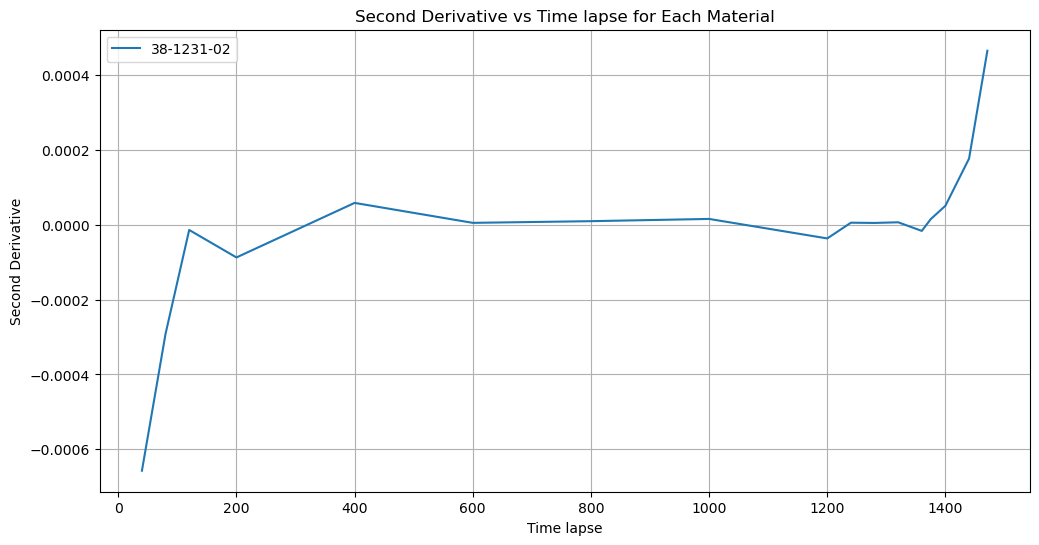

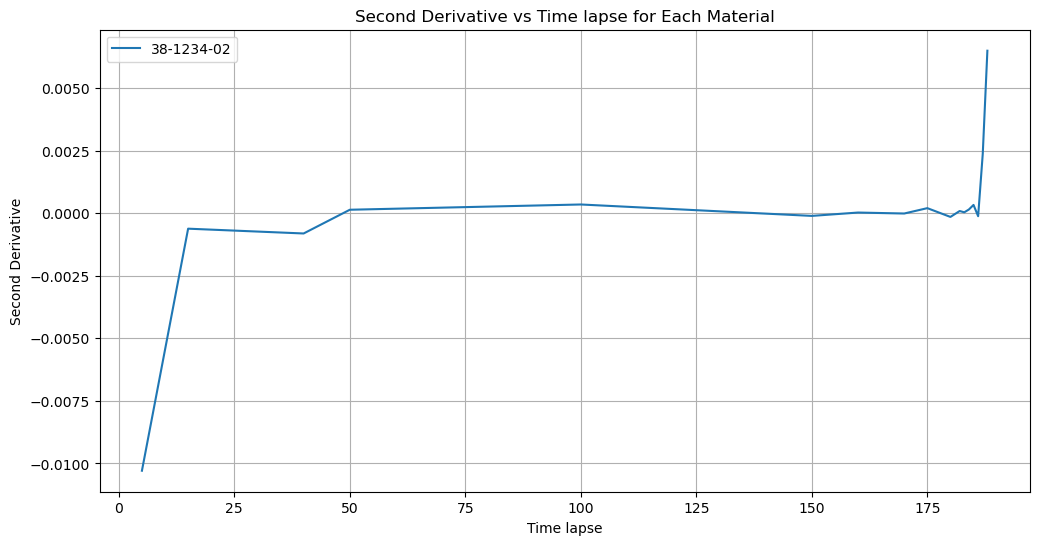

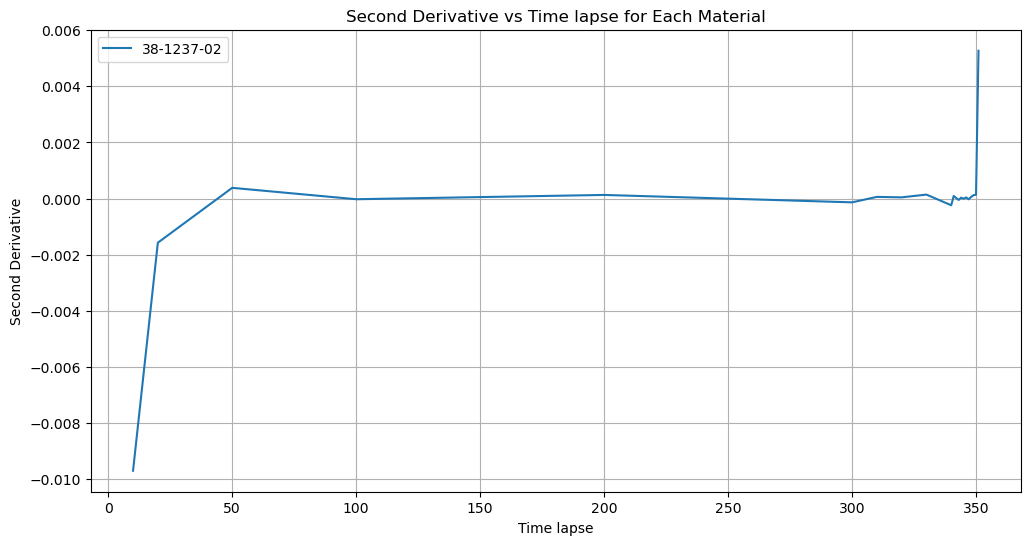

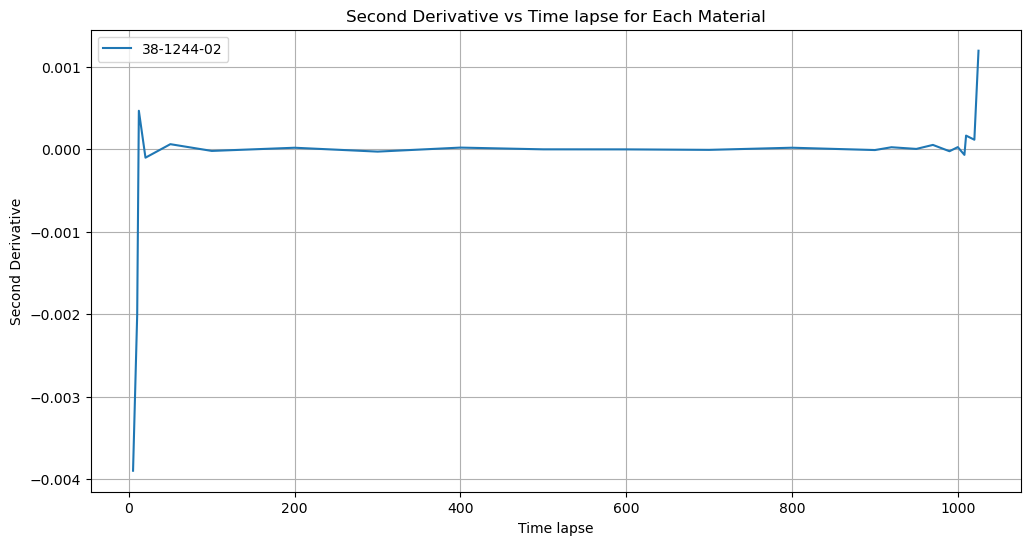

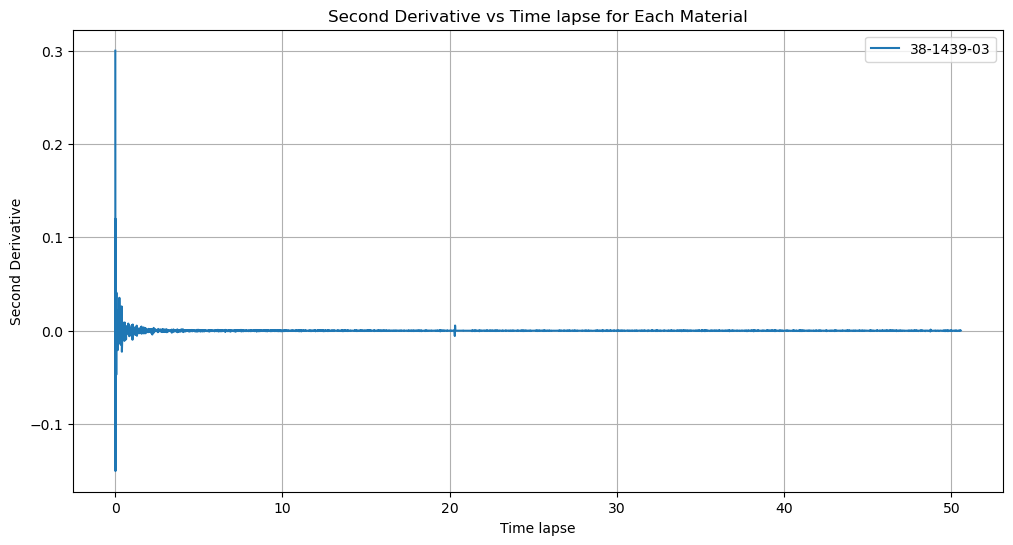

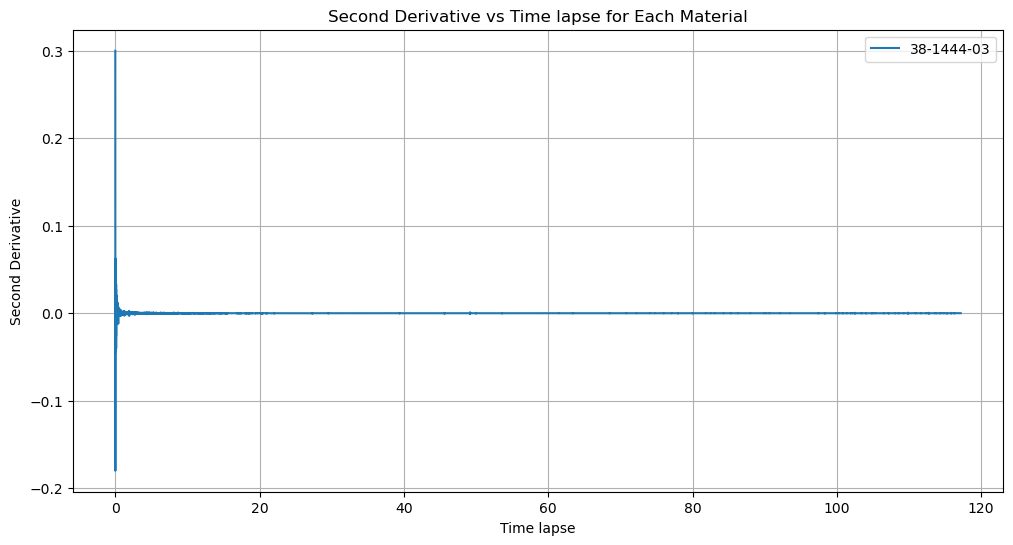

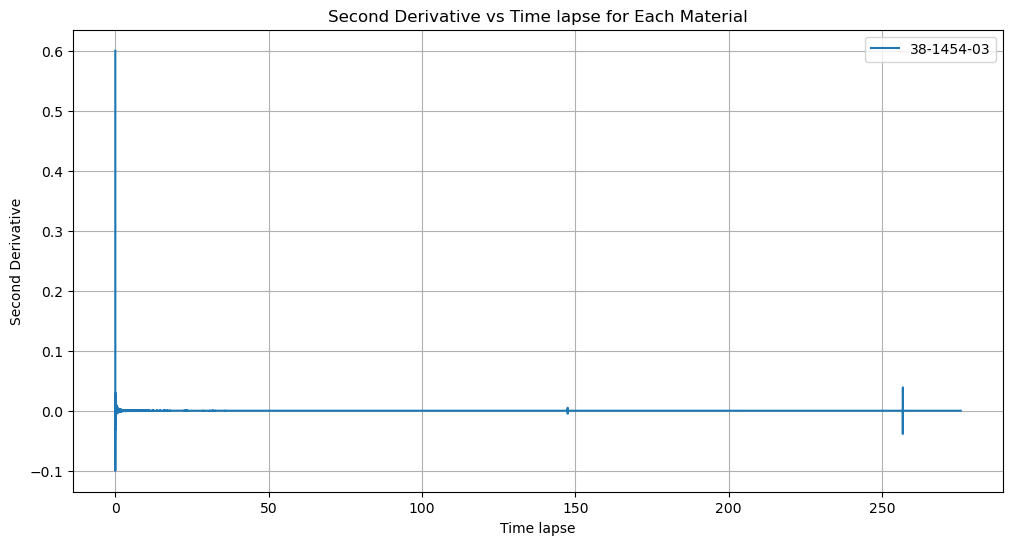

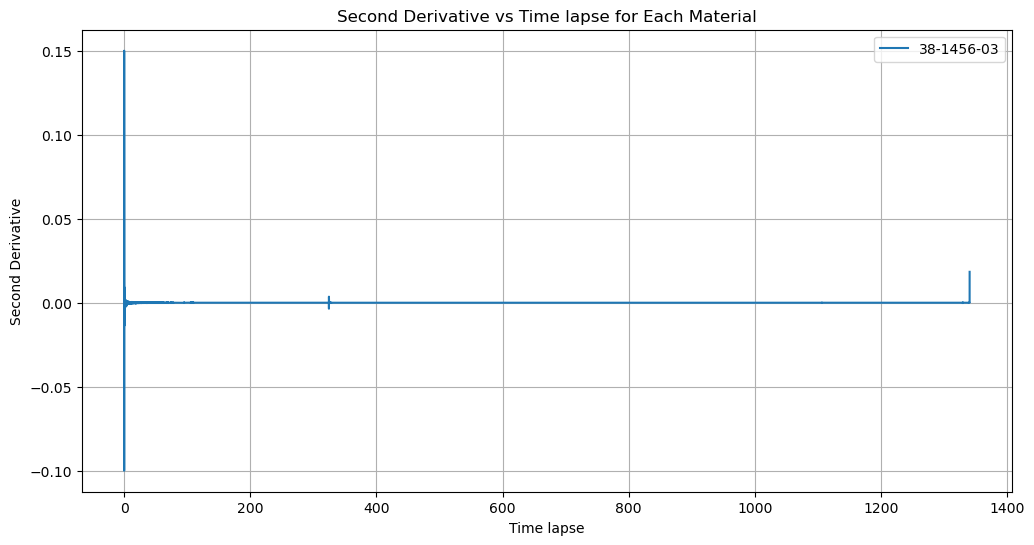

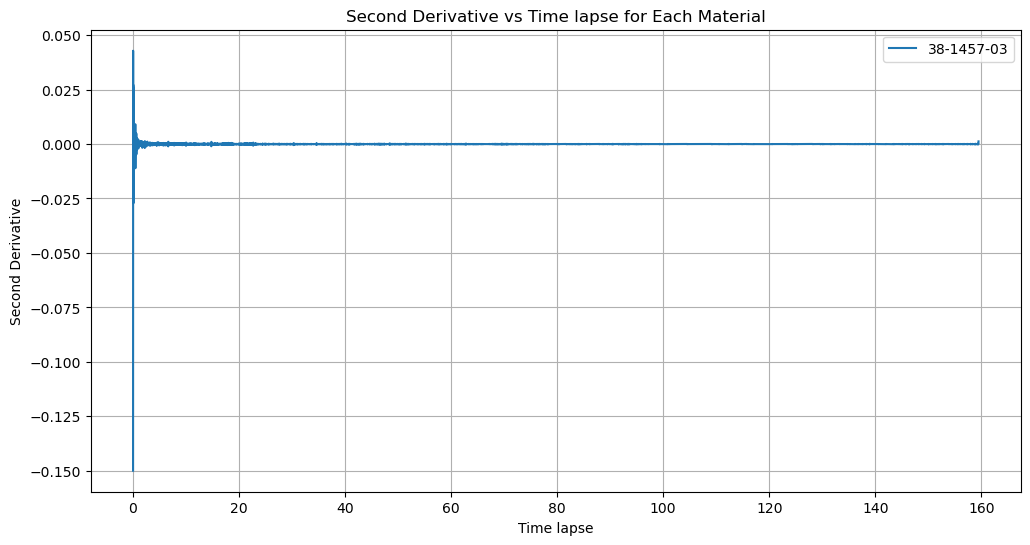

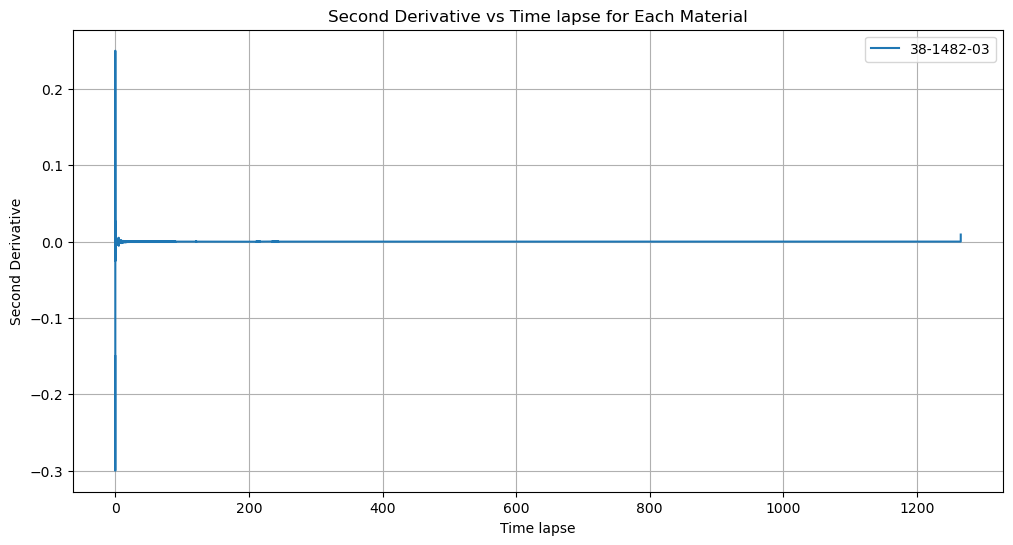

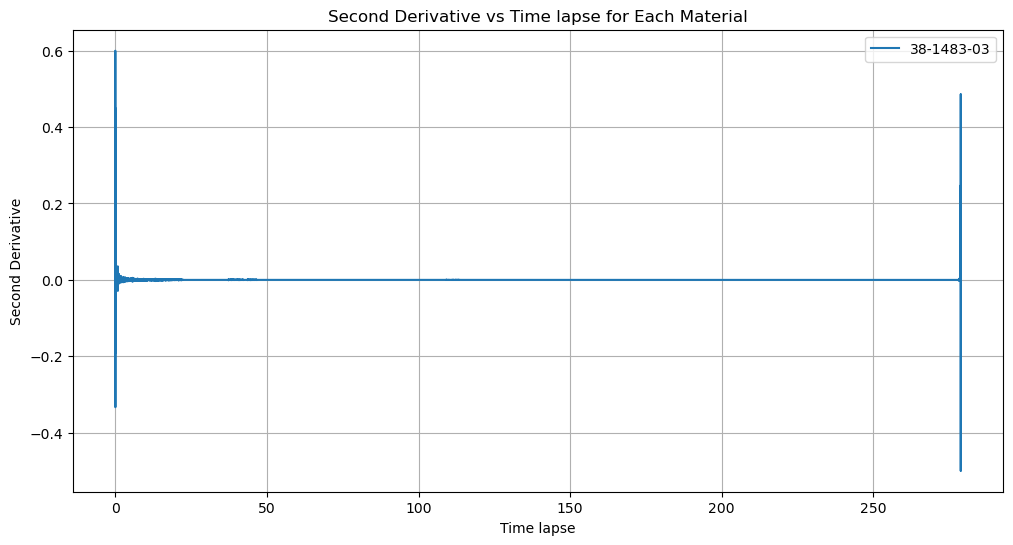

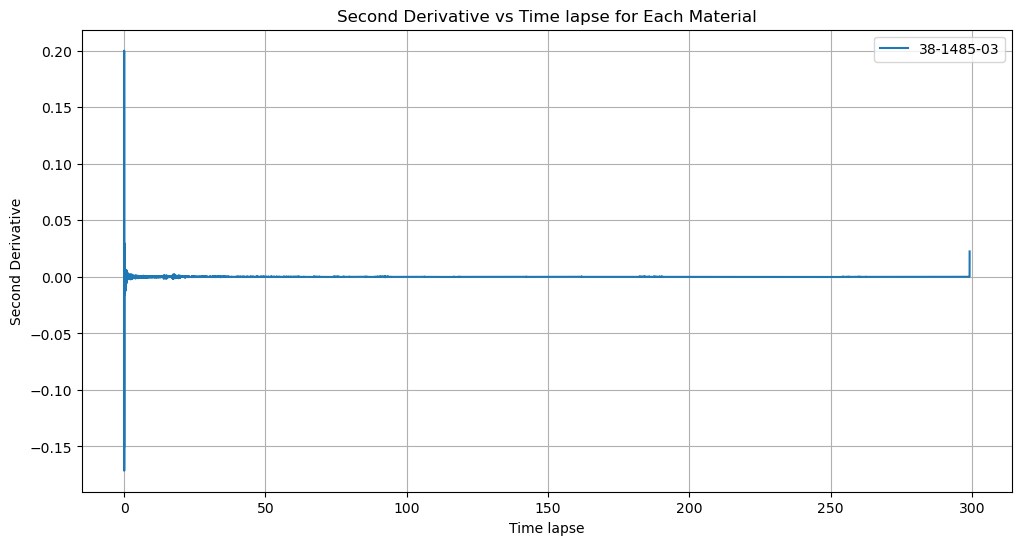

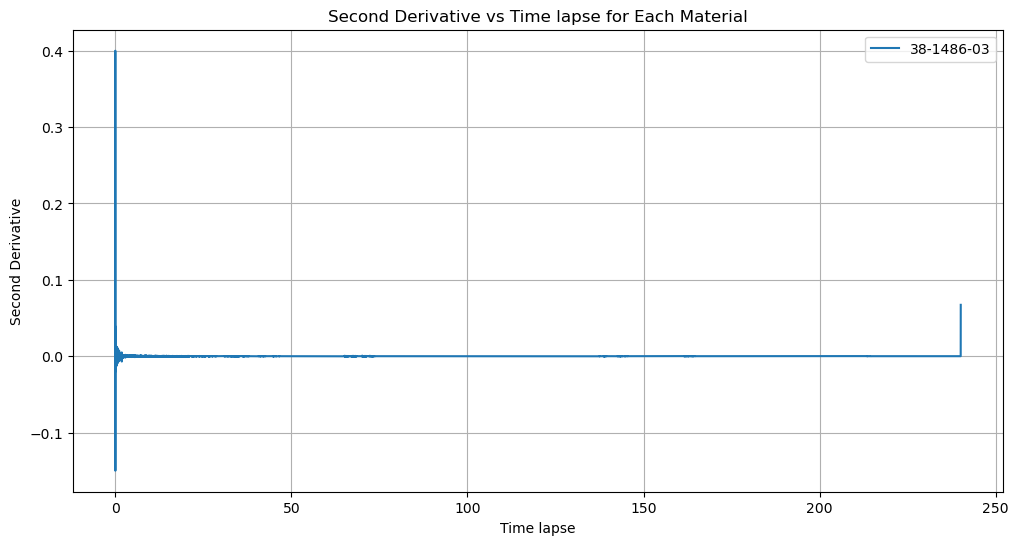

In [24]:
for material, group in results_df.groupby("Material"):
    plt.figure(figsize=(12, 6))
    plt.plot(group["Time lapse"], group["Second Derivative"], label=material)

    plt.xlabel("Time lapse")
    plt.ylabel("Second Derivative")
    plt.title("Second Derivative vs Time lapse for Each Material")
    plt.legend()
    plt.grid(True)
    plt.show()

Результаты сохранены в файл: second_derivatives.csv


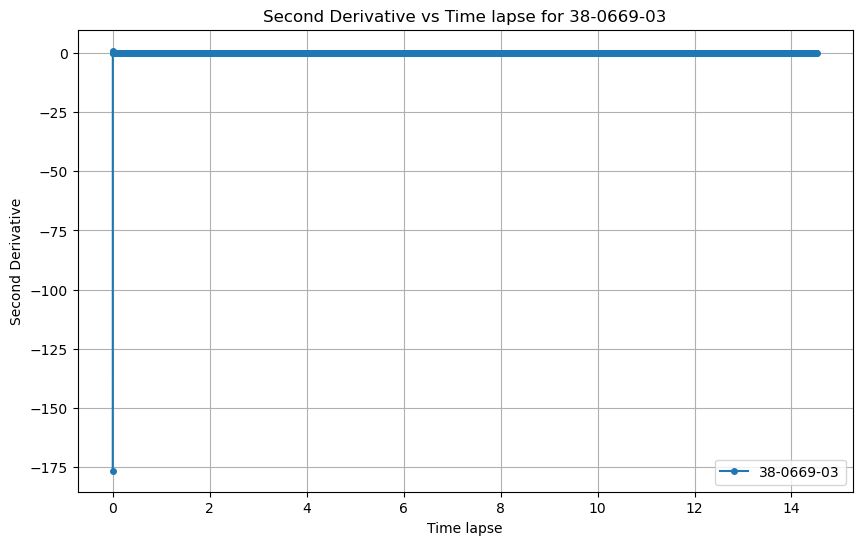

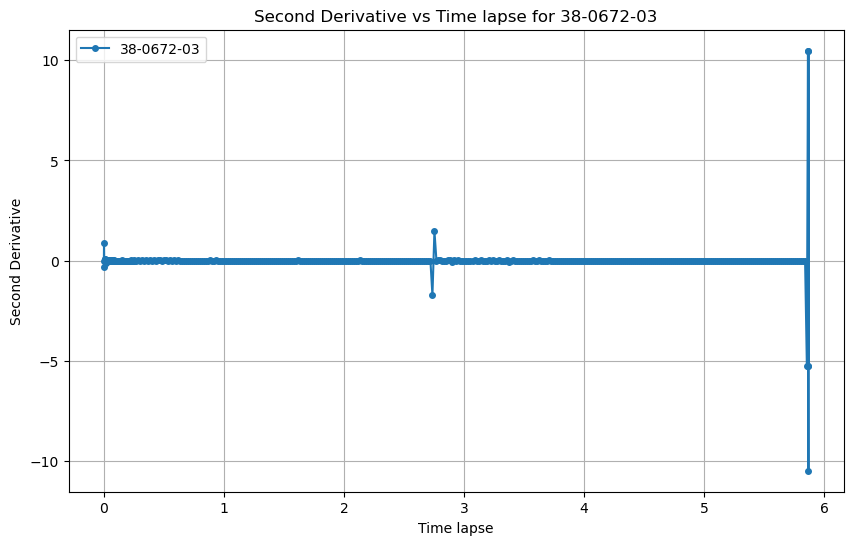

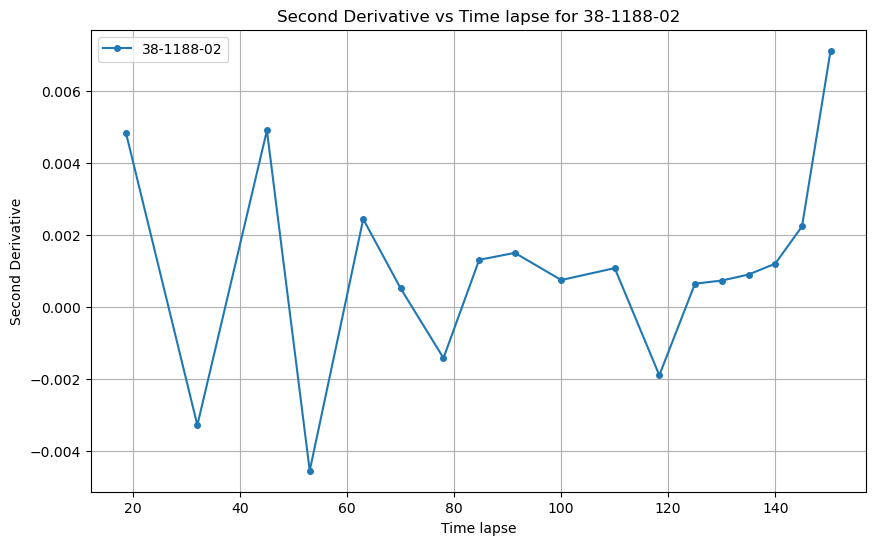

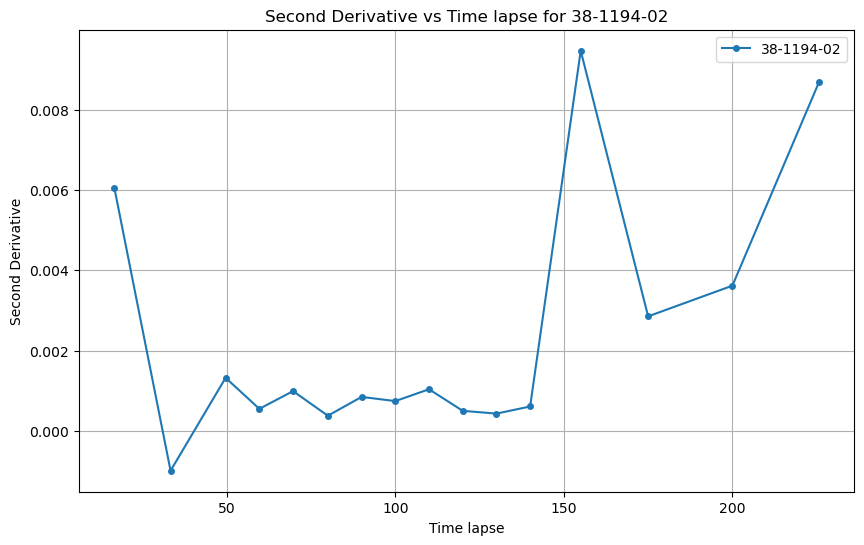

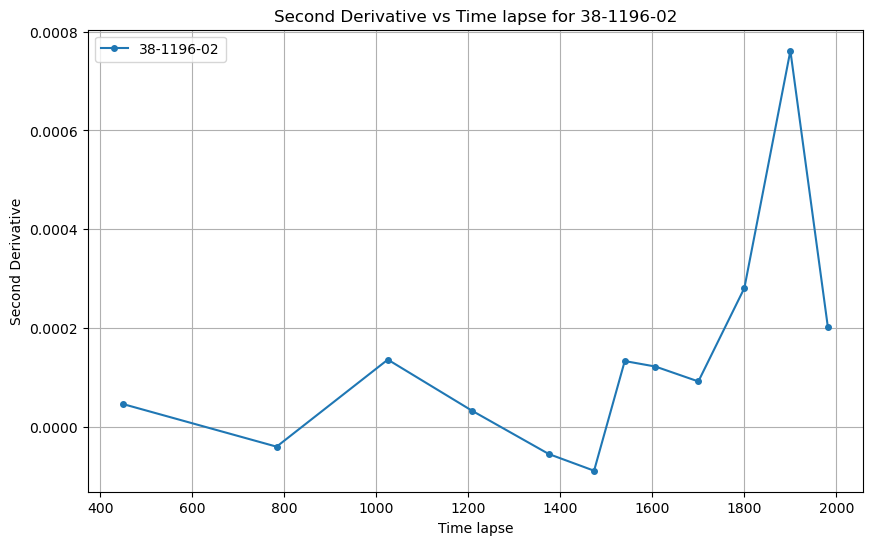

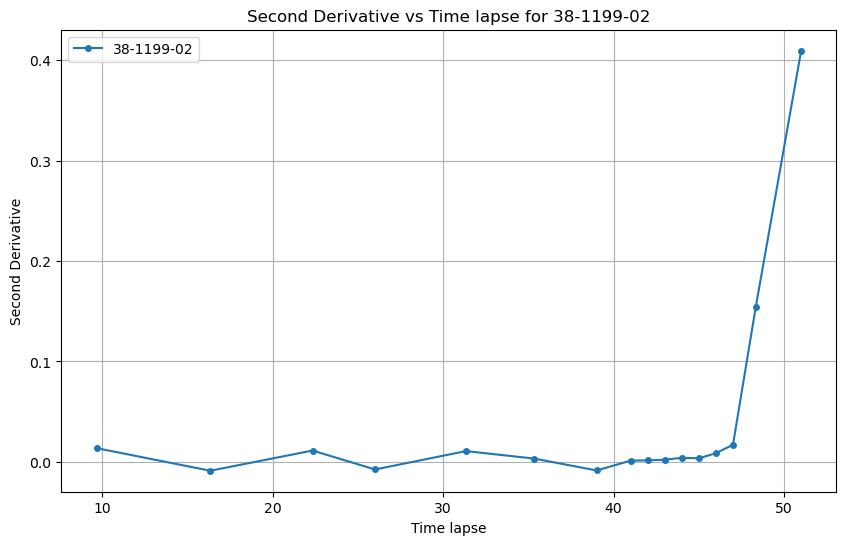

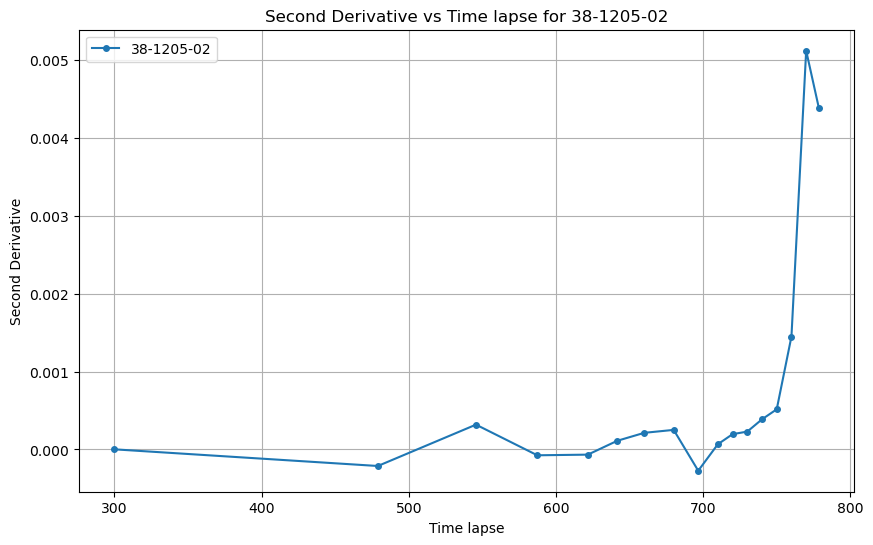

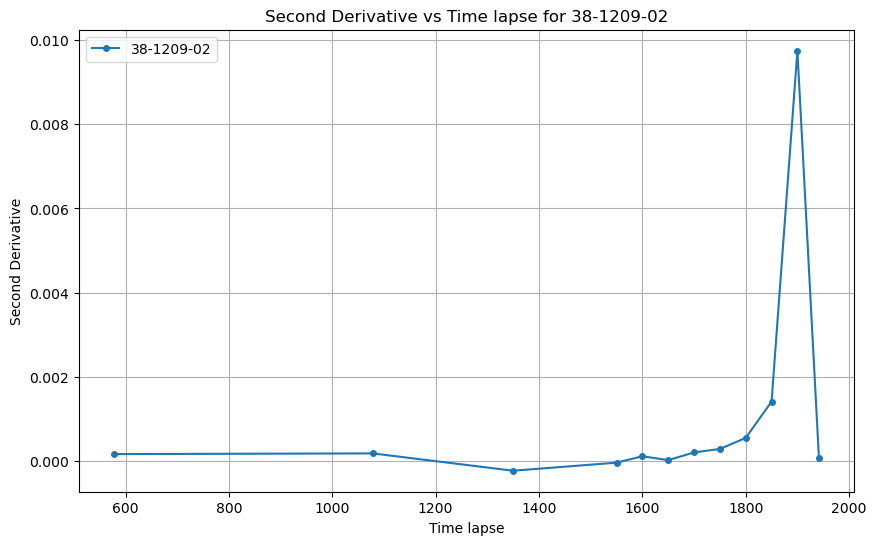

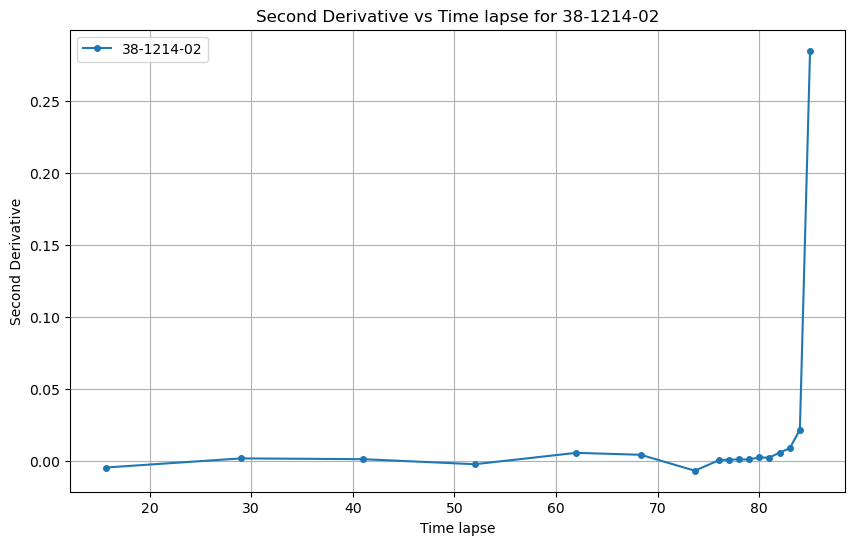

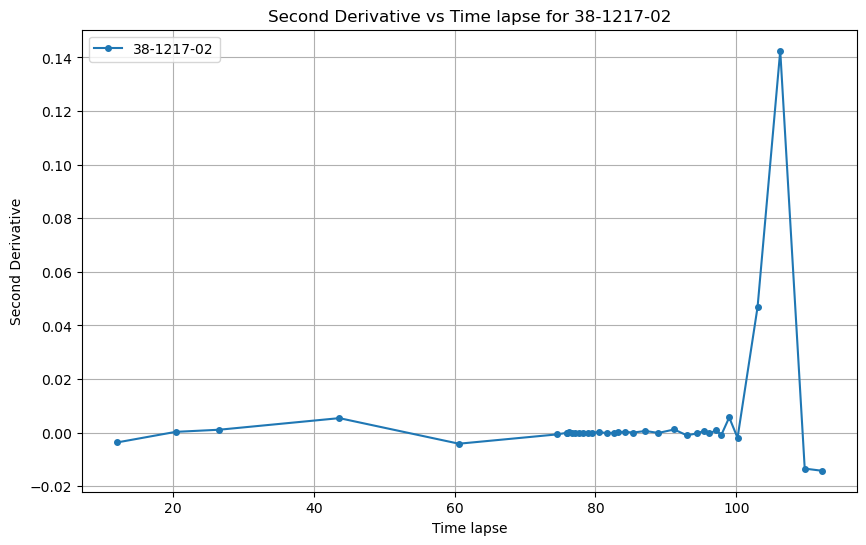

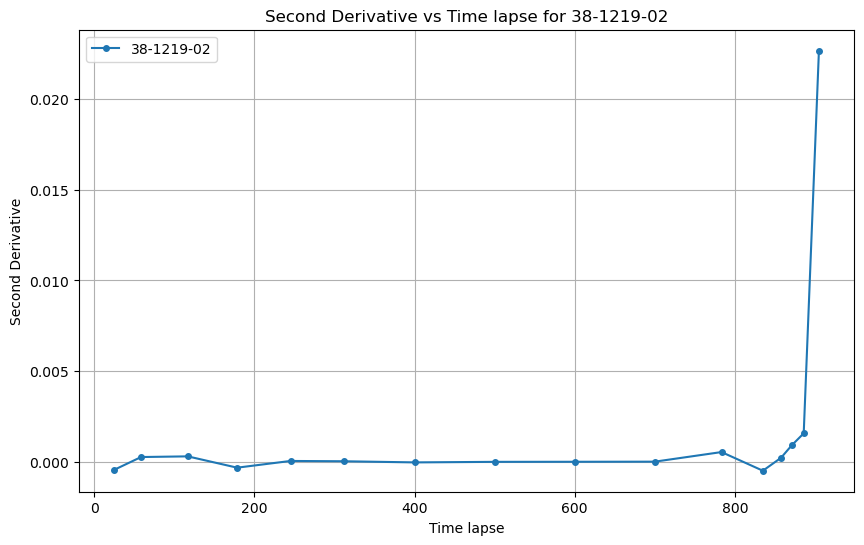

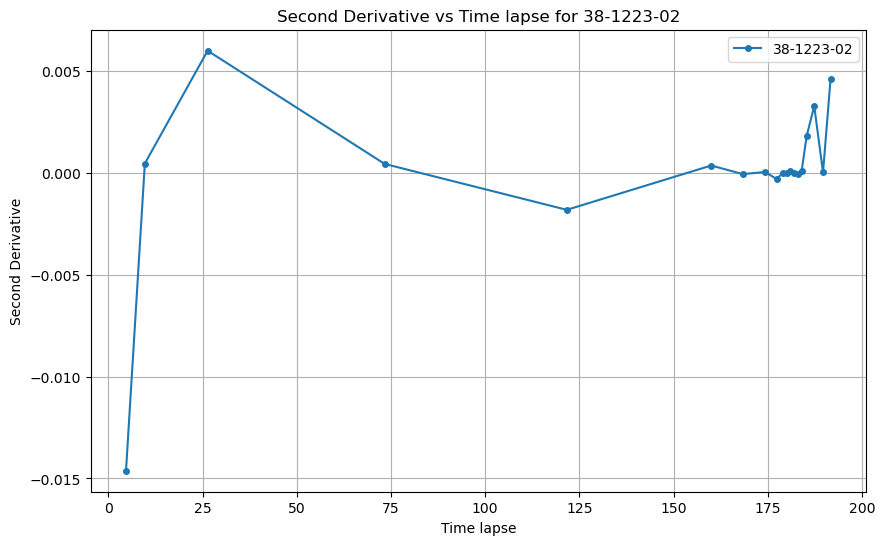

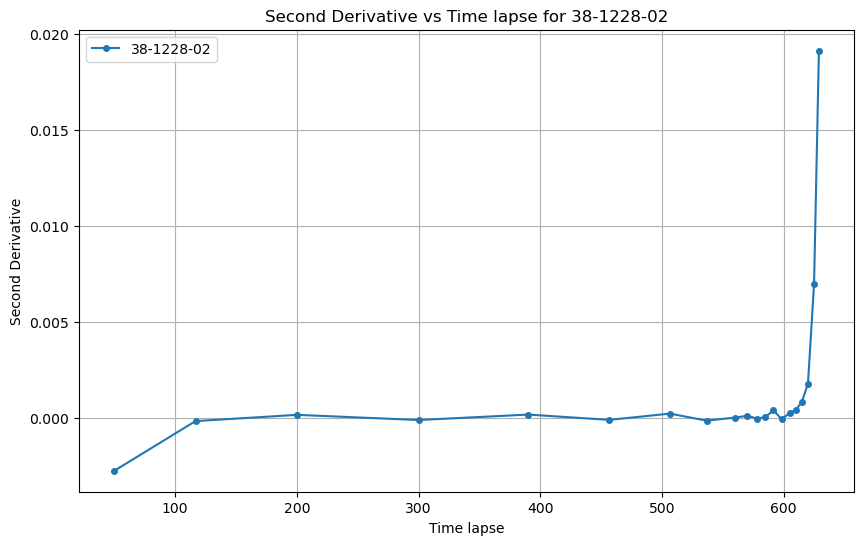

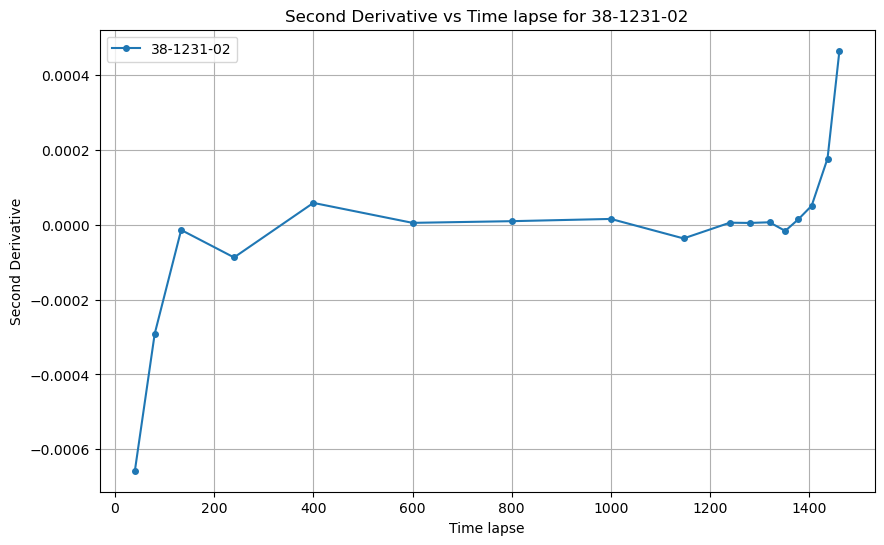

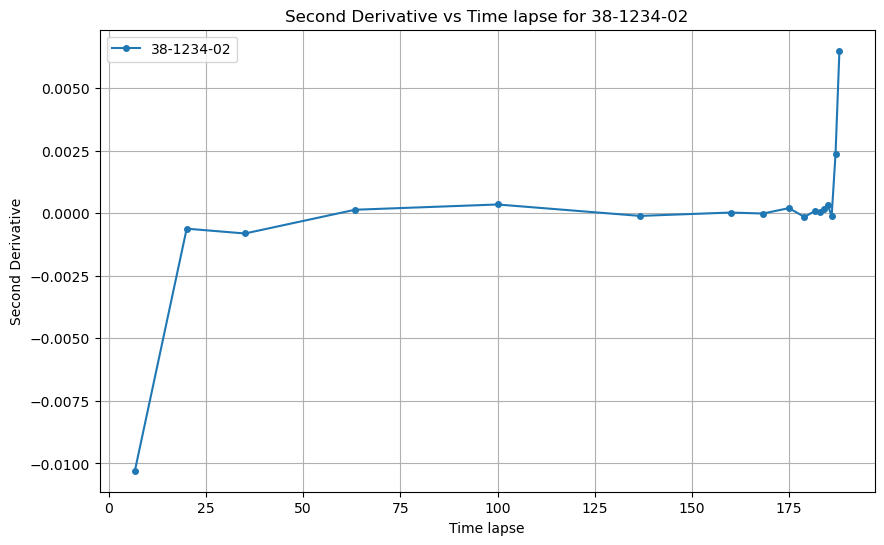

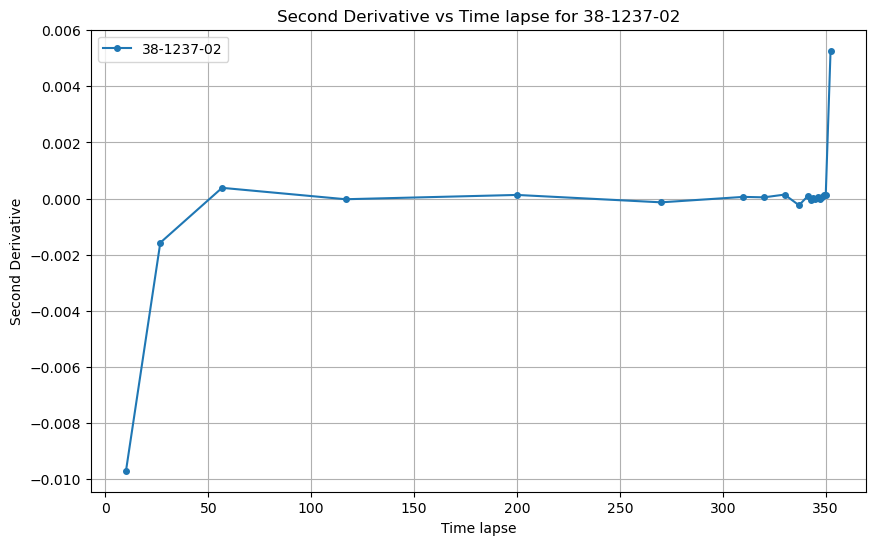

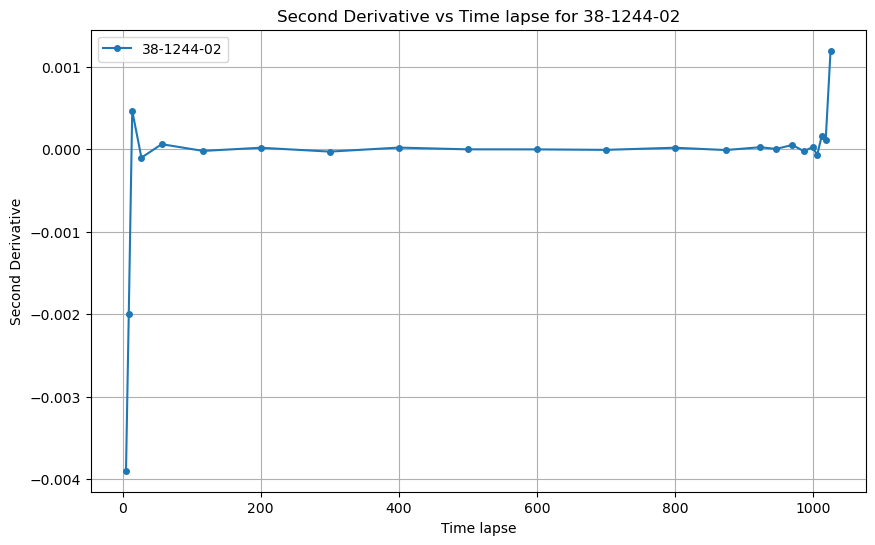

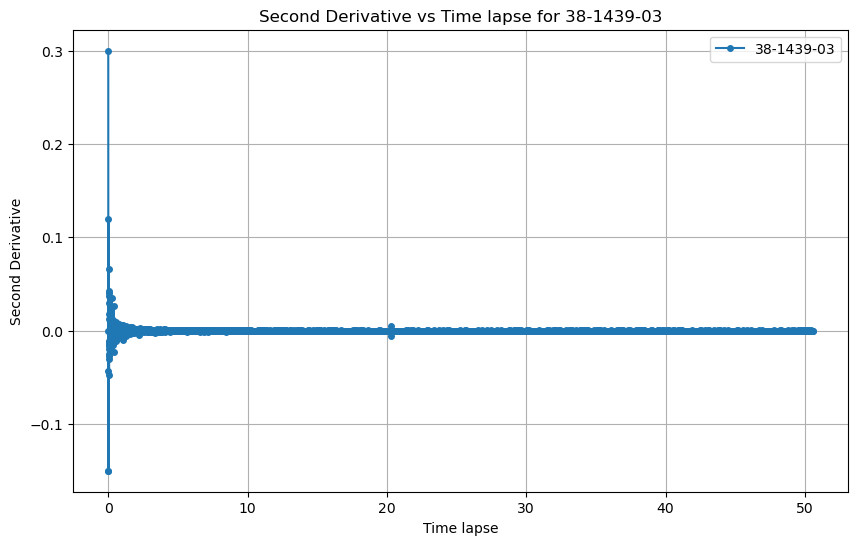

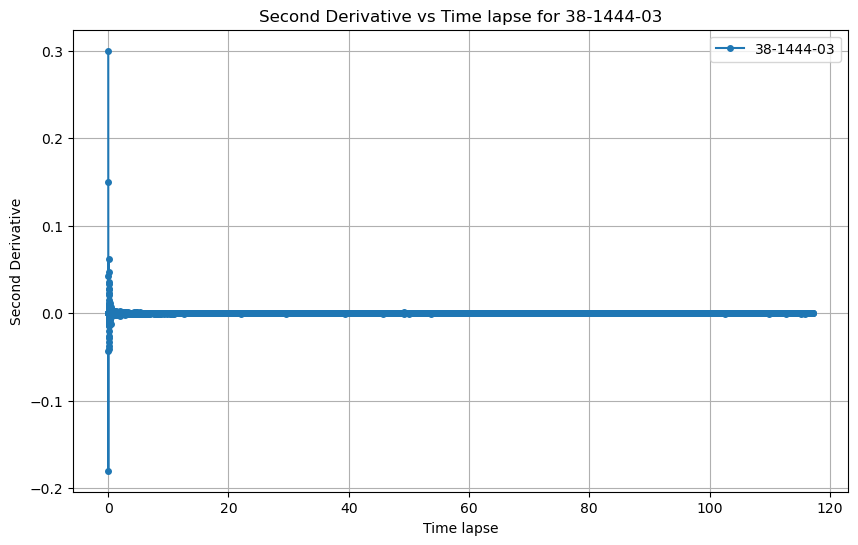

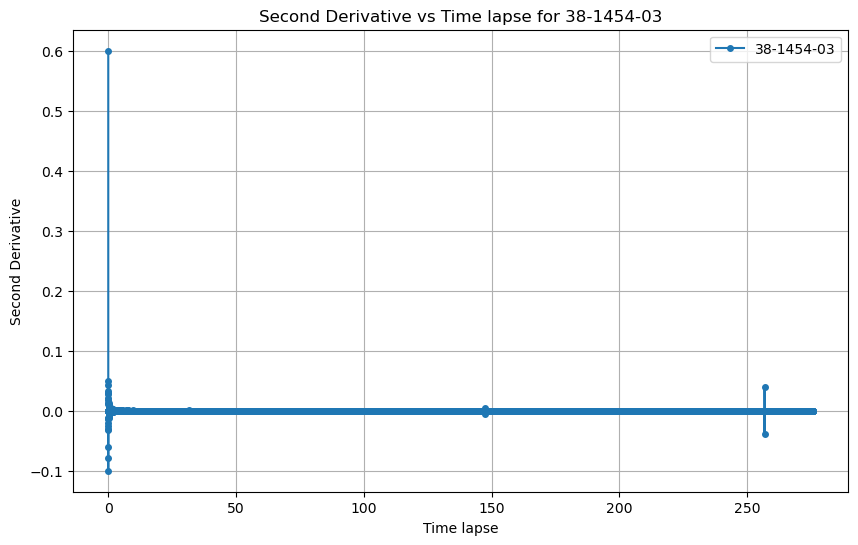

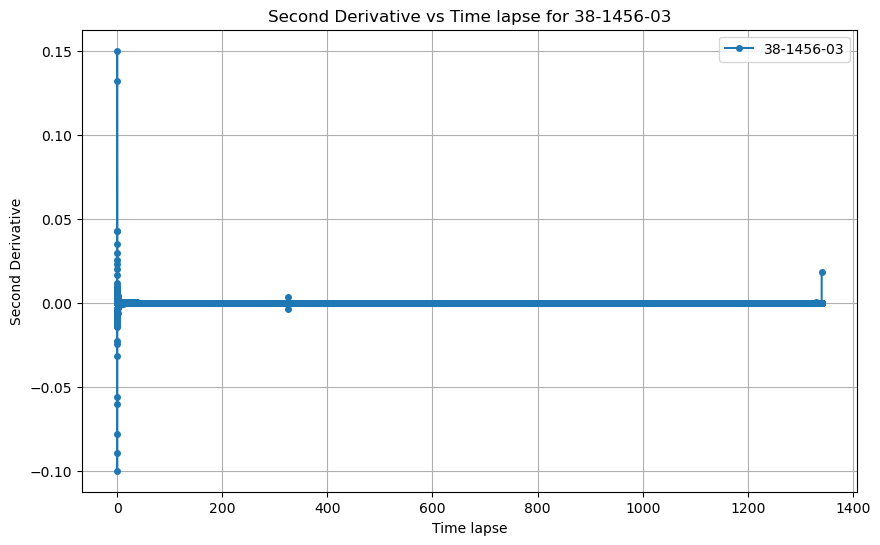

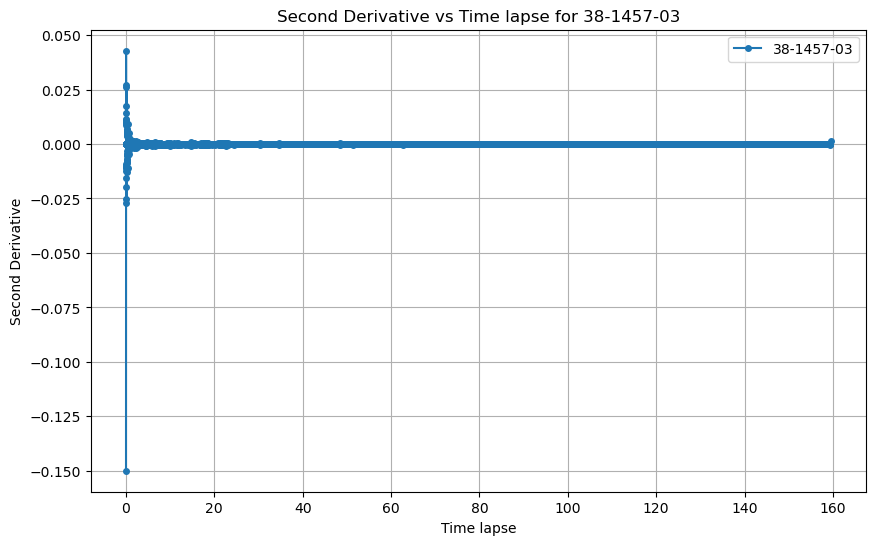

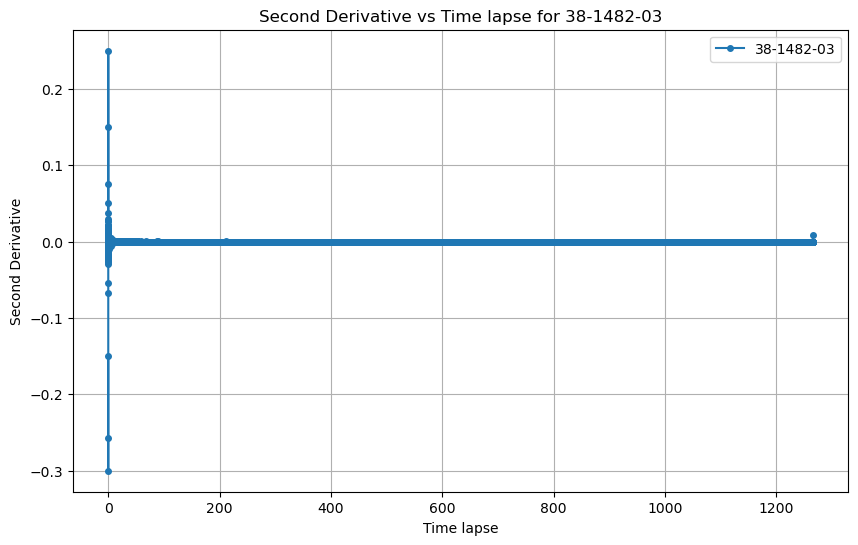

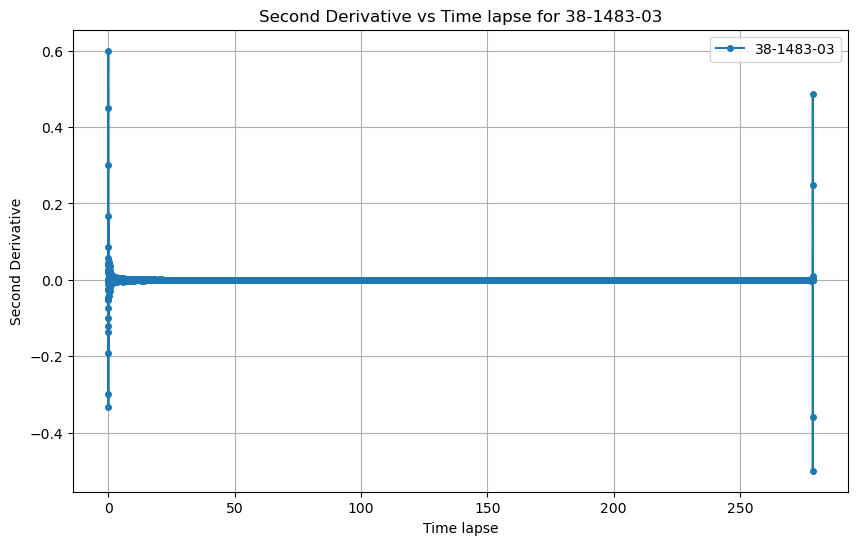

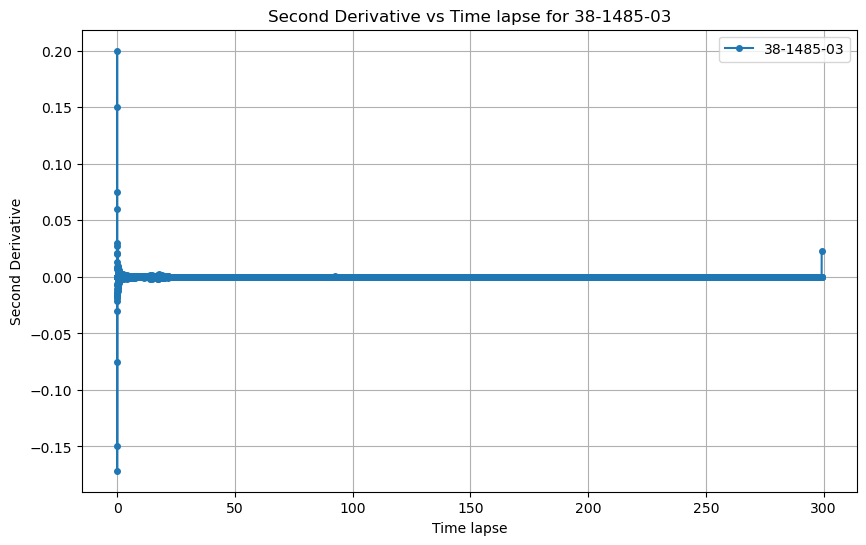

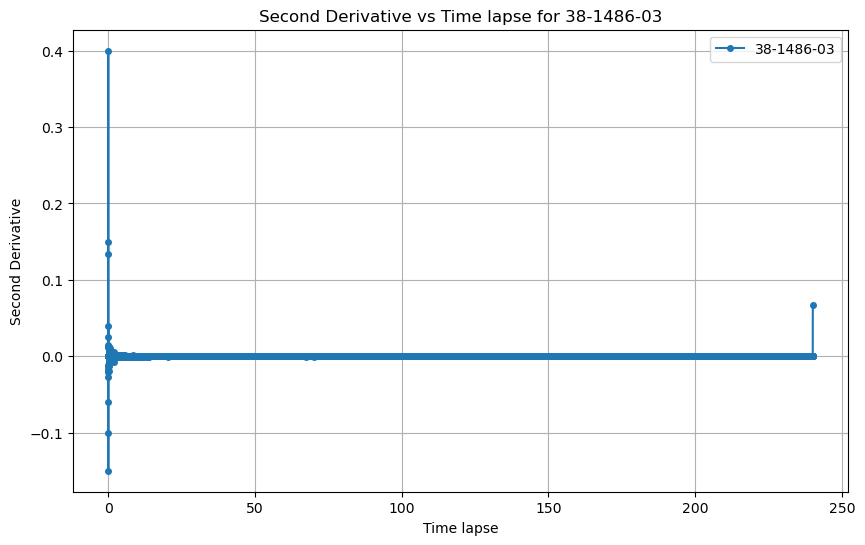

In [26]:
def calculate_second_derivative(group):
    second_derivatives = []
    time_values = []
    for i in range(1, len(group) - 1):  # Пропускаем первый и последний элементы
        deformation_diff = (
            group["Deformation"].iloc[i - 1] 
            - 2 * group["Deformation"].iloc[i] 
            + group["Deformation"].iloc[i + 1]
        )
        time_avg = (
            group["Time lapse"].iloc[i - 1] 
            + group["Time lapse"].iloc[i] 
            + group["Time lapse"].iloc[i + 1]
        ) / 3
        if time_avg != 0:  # Избегаем деления на ноль
            second_derivative = deformation_diff / time_avg
        else:
            second_derivative = None  # Если time_avg = 0, записываем None
        second_derivatives.append(second_derivative)
        time_values.append(time_avg)
    return time_values, second_derivatives

# Применение функции к каждому материалу и сохранение результатов
results = []
for material, group in df.groupby("Material"):
    time_values, second_derivatives = calculate_second_derivative(group)
    for time, derivative in zip(time_values, second_derivatives):
        results.append({
            "Material": material,
            "Time lapse": time,
            "Second Derivative": derivative
        })

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Запись результатов в CSV-файл
output_file = "second_derivatives.csv"
results_df.to_csv(output_file, index=False)

print(f"Результаты сохранены в файл: {output_file}")

# Построение отдельных графиков для каждого материала
for material in results_df["Material"].unique():
    material_data = results_df[results_df["Material"] == material]
    
    plt.figure(figsize=(10, 6))
    plt.plot(material_data["Time lapse"], material_data["Second Derivative"], label=material, marker="o",markersize=4)
    
    plt.xlabel("Time lapse")
    plt.ylabel("Second Derivative")
    plt.title(f"Second Derivative vs Time lapse for {material}")
    plt.legend()
    plt.grid(True)
    plt.show()

Результаты сохранены в файл: first_derivatives.csv


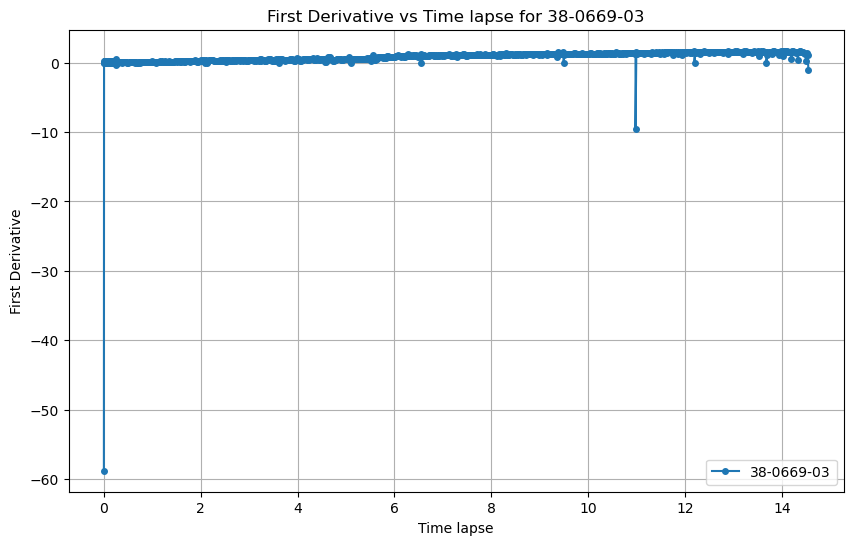

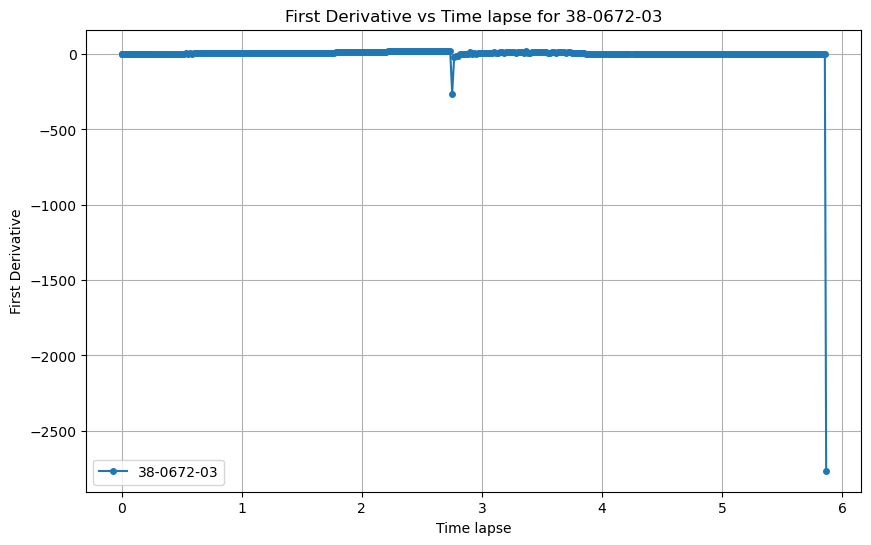

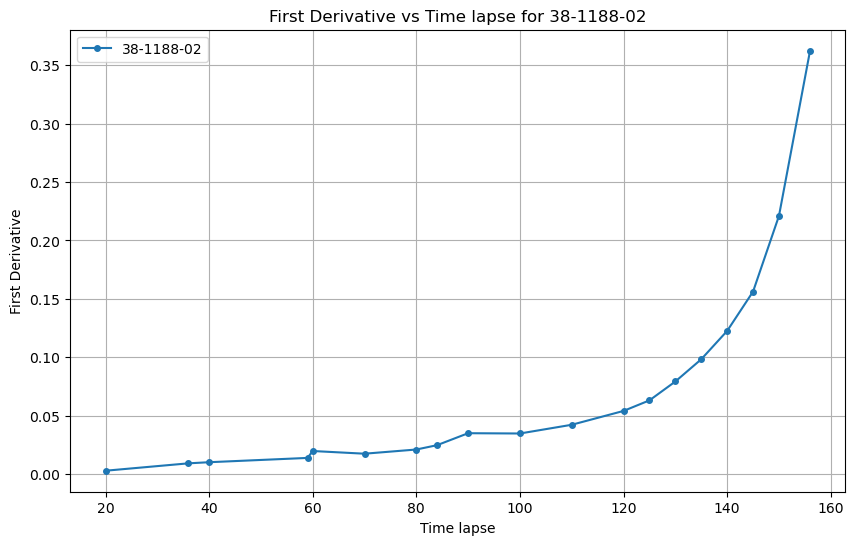

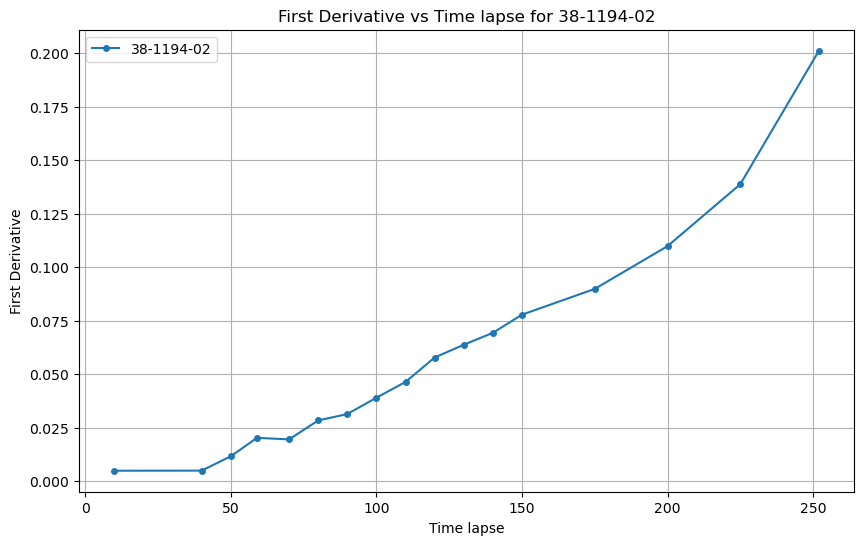

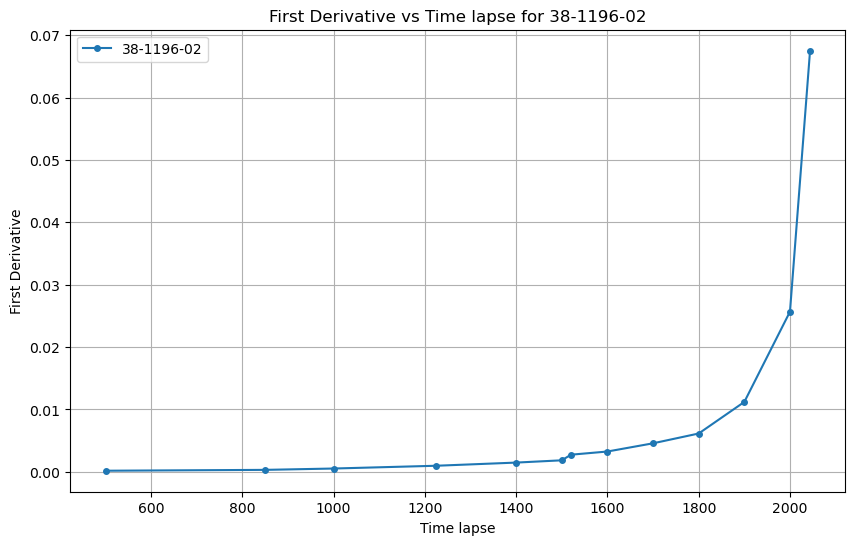

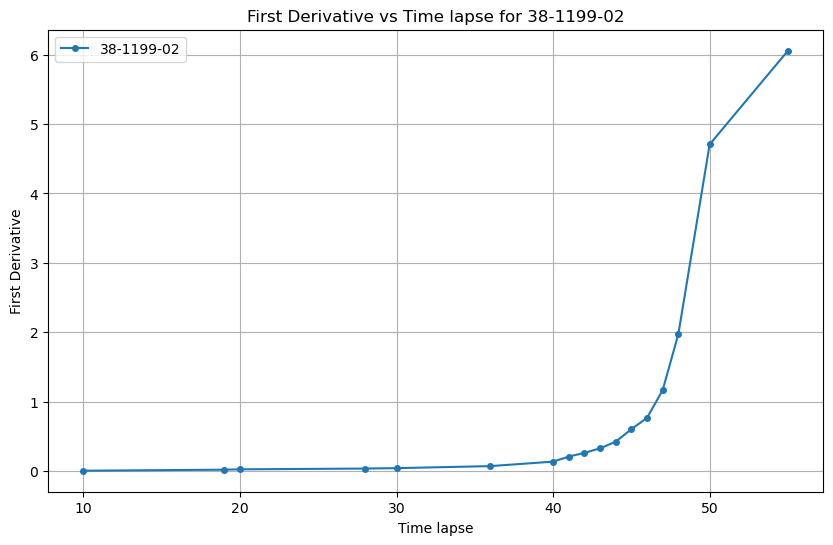

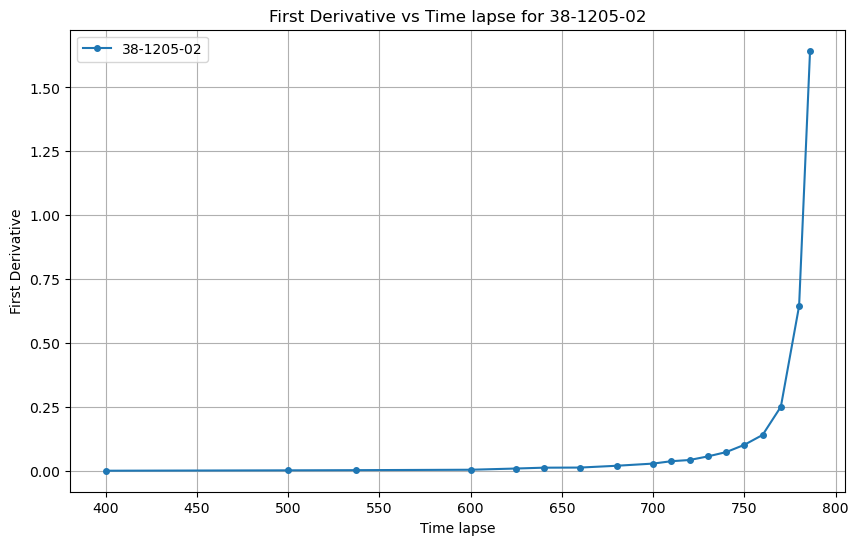

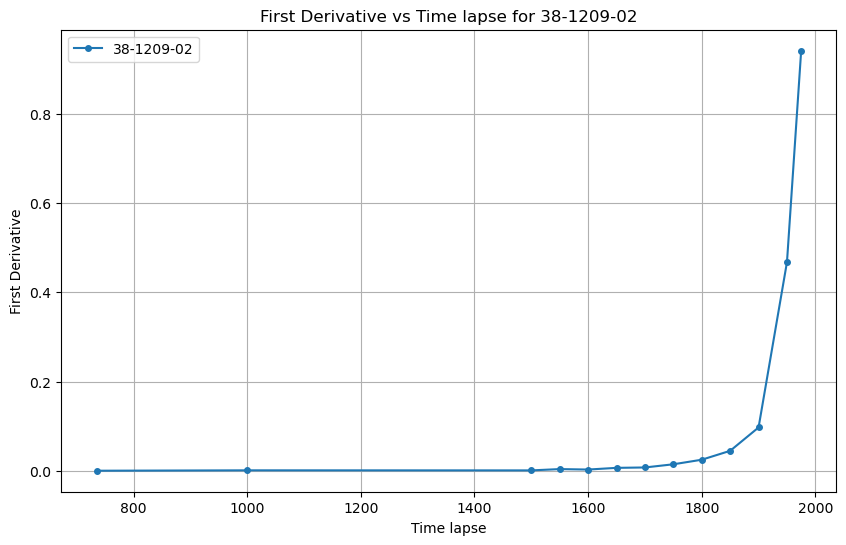

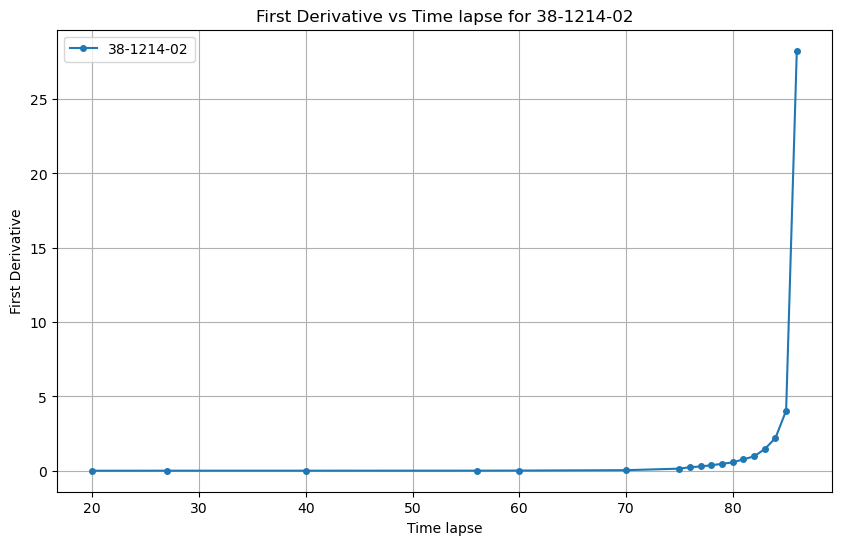

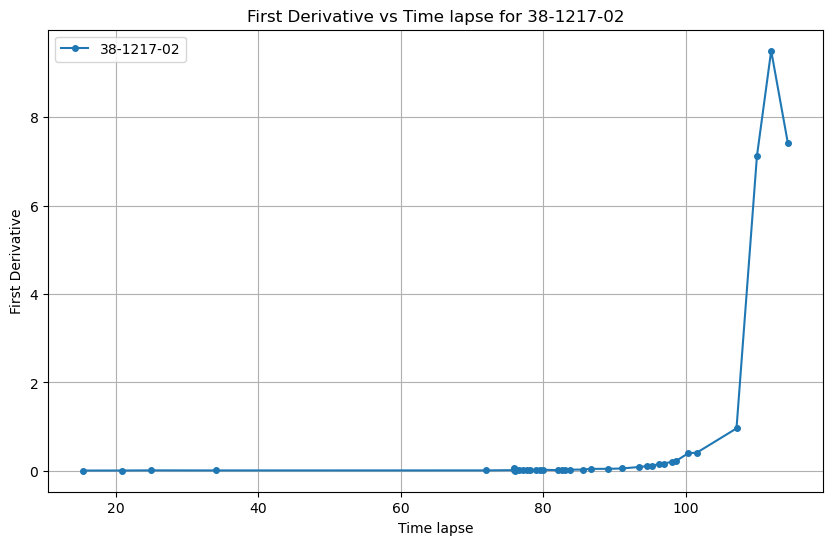

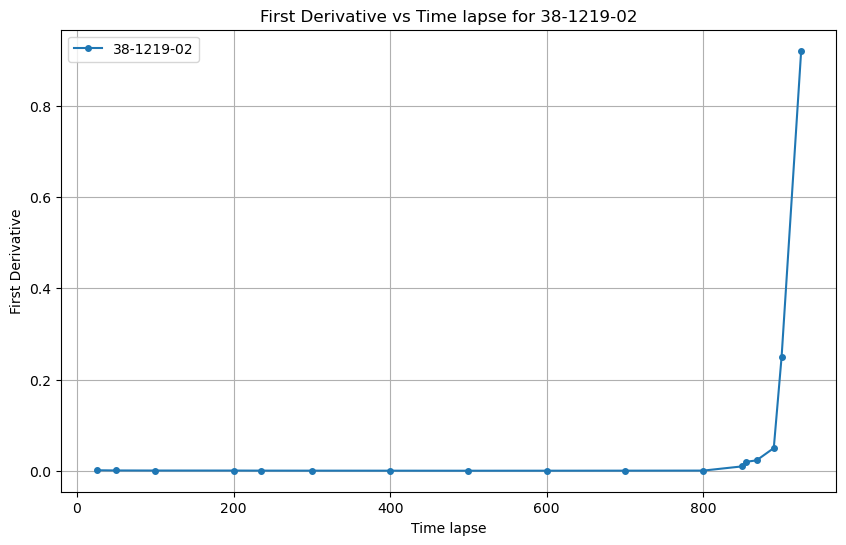

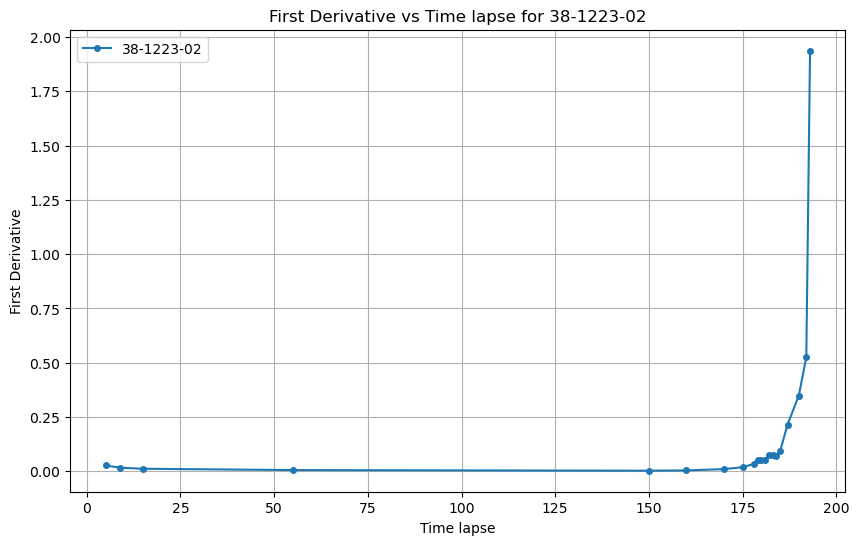

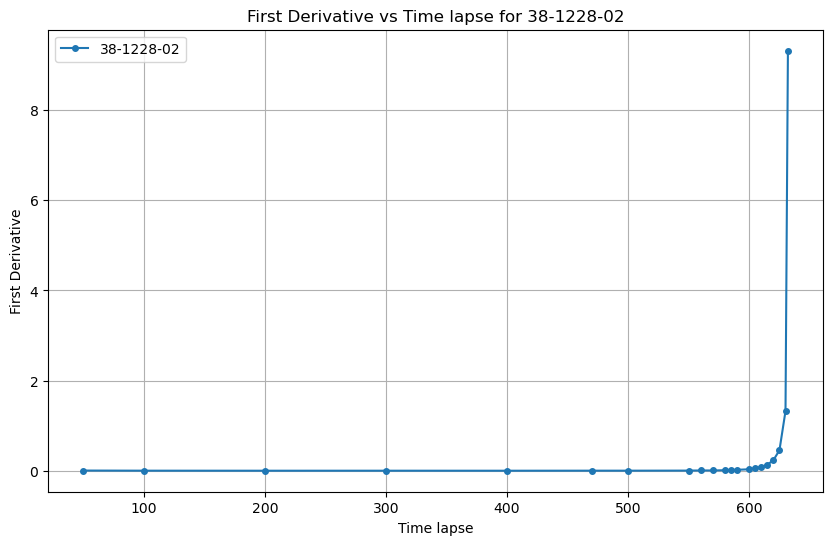

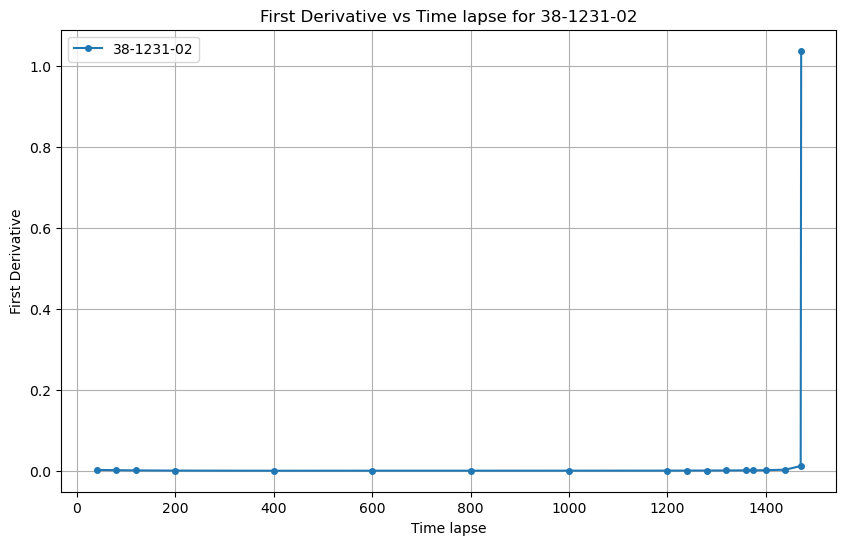

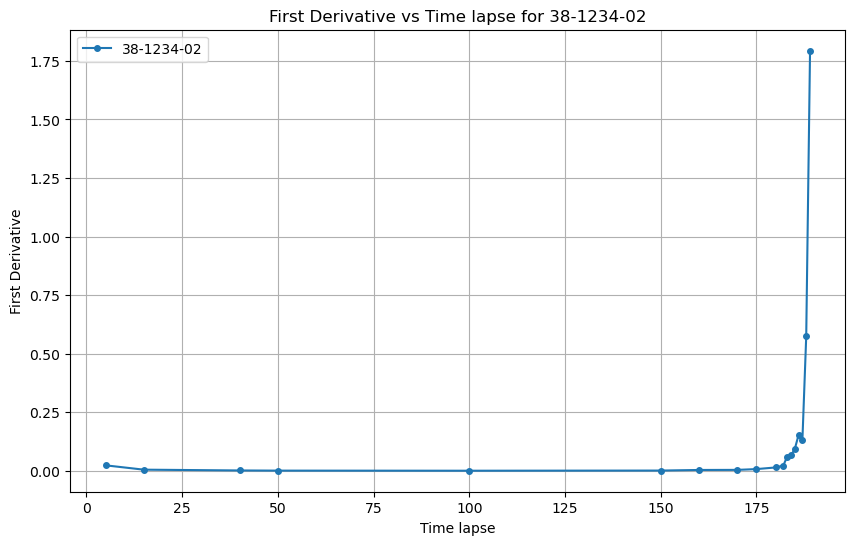

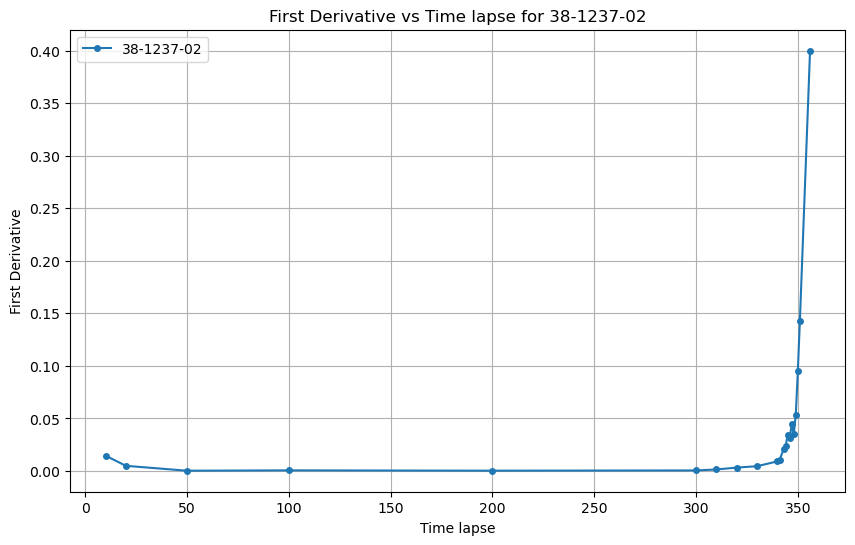

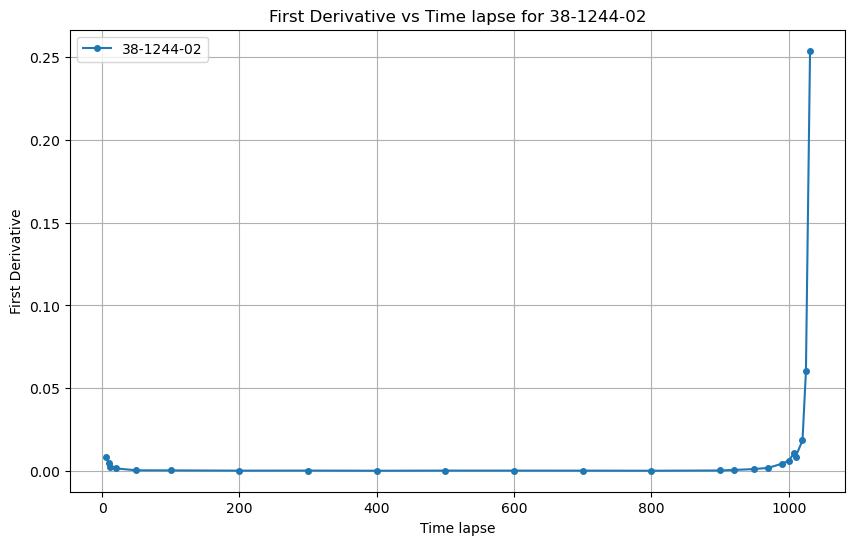

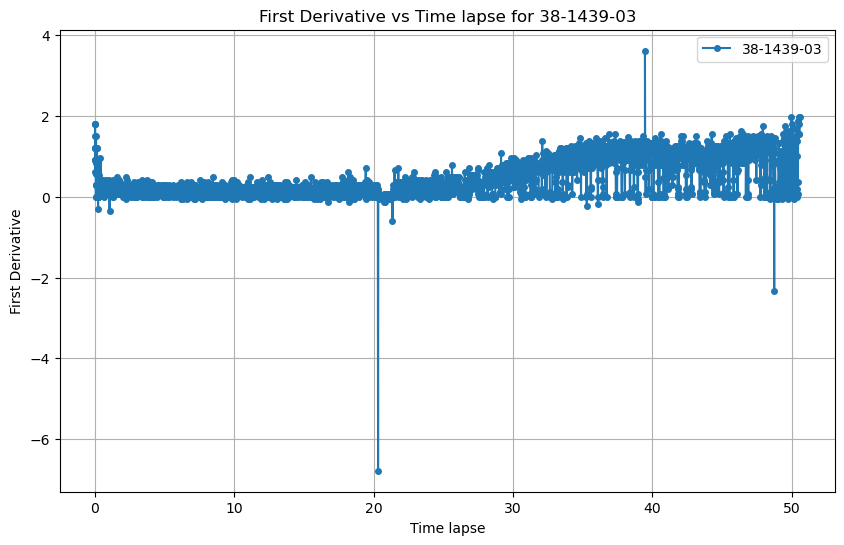

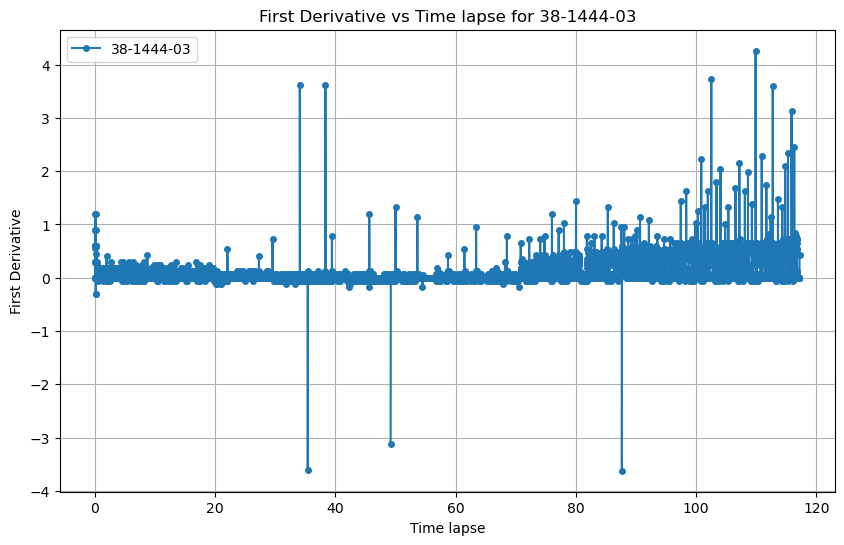

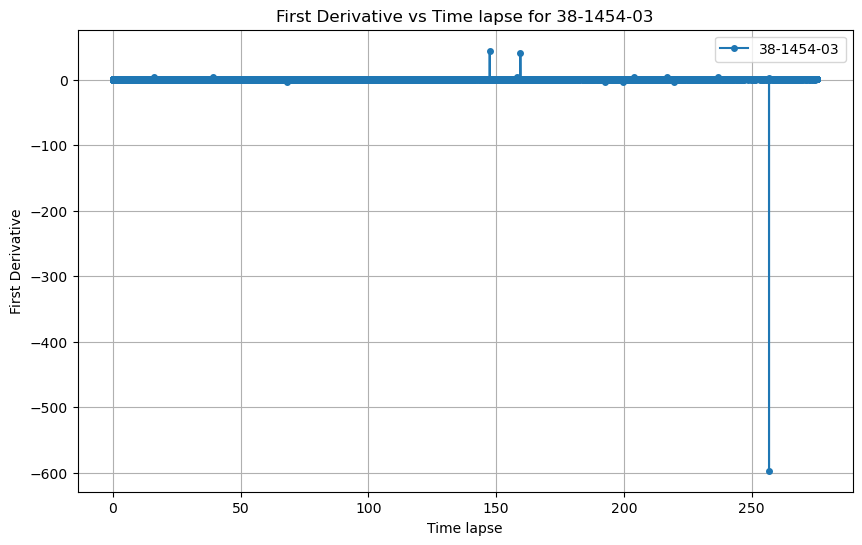

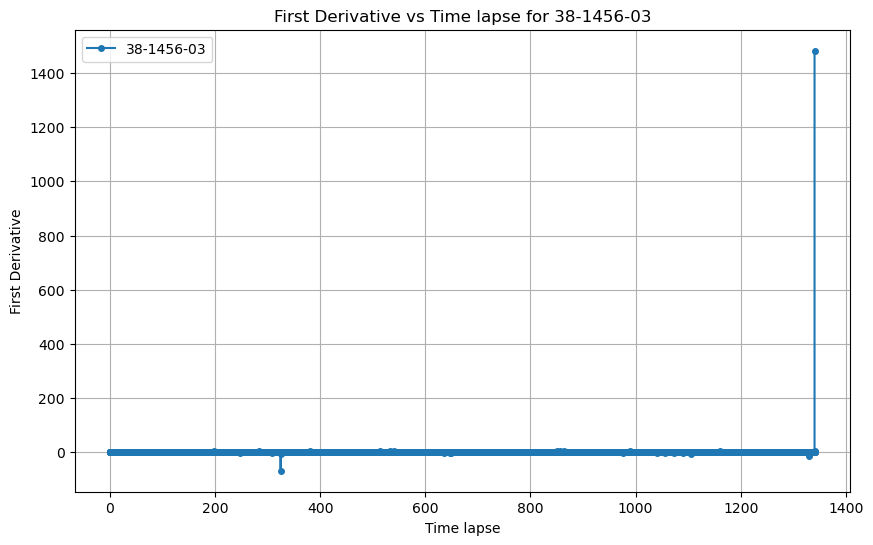

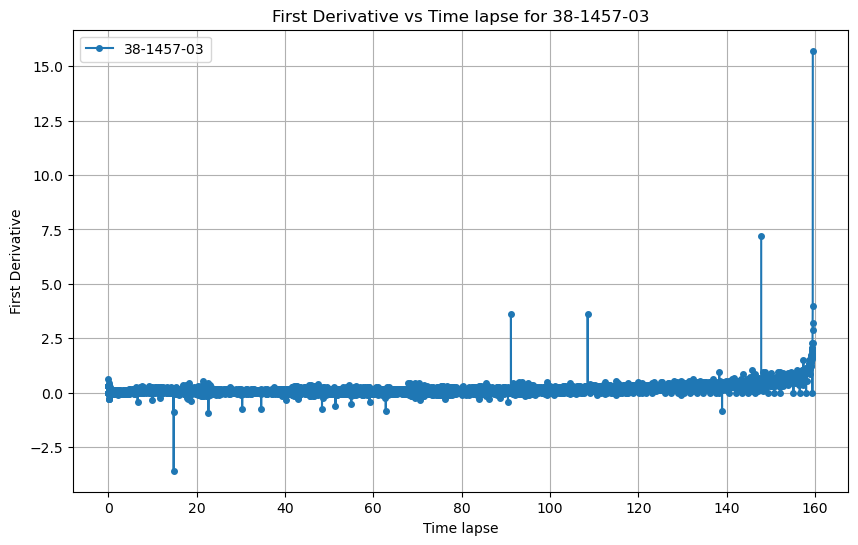

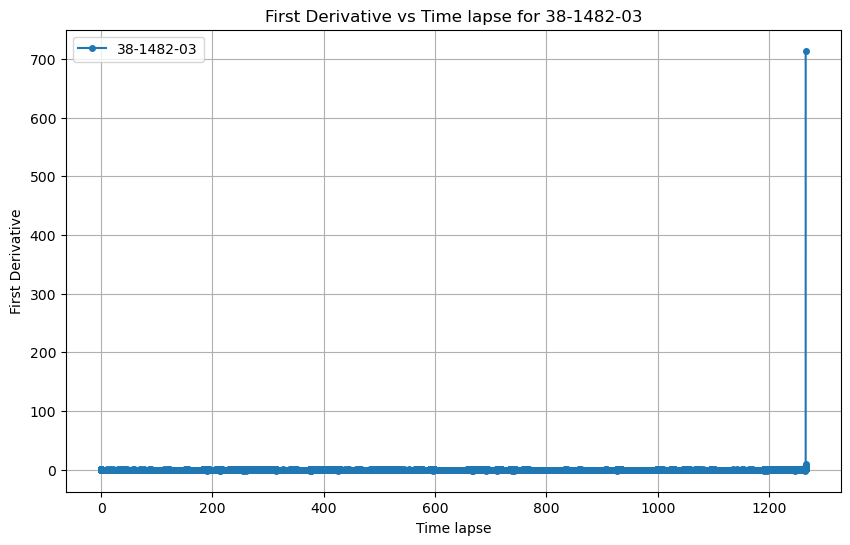

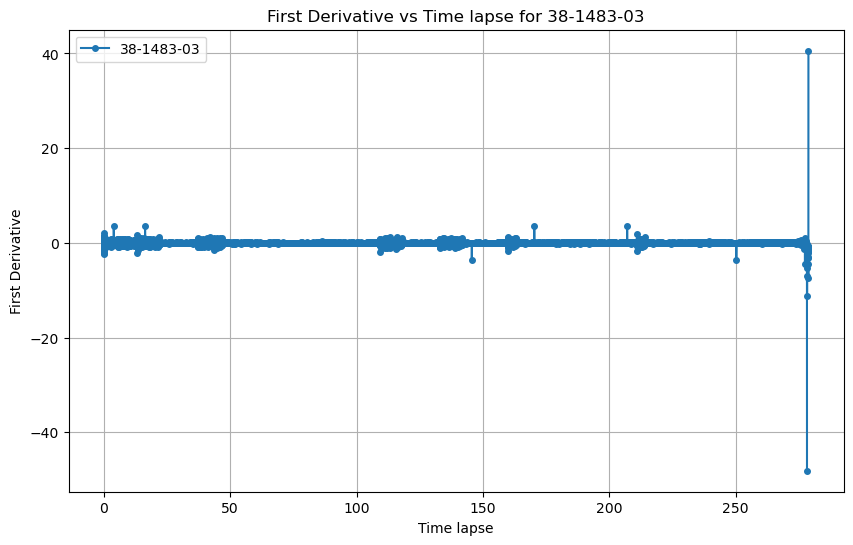

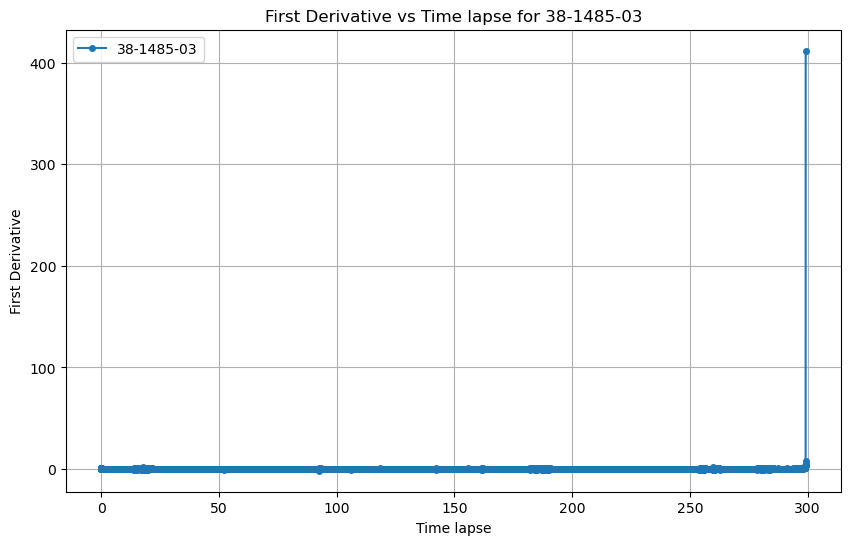

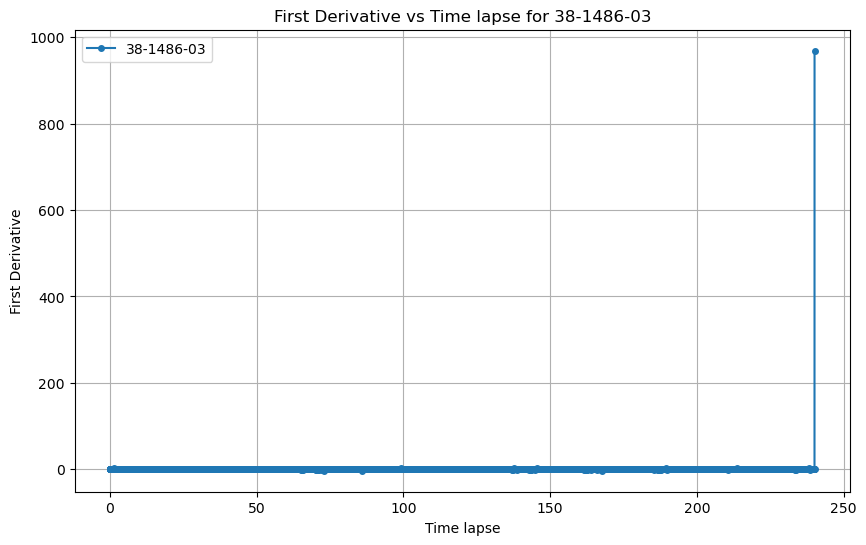

In [27]:
def calculate_first_derivative(group):
    first_derivatives = []
    time_values = []
    for i in range(1, len(group)):  # Начинаем с 1, чтобы использовать i-1
        deformation_diff = group["Deformation"].iloc[i] - group["Deformation"].iloc[i - 1]
        time_diff = group["Time lapse"].iloc[i] - group["Time lapse"].iloc[i - 1]
        if time_diff != 0:  # Избегаем деления на ноль
            first_derivative = deformation_diff / time_diff
        else:
            first_derivative = None  # Если time_diff = 0, записываем None
        first_derivatives.append(first_derivative)
        time_values.append(group["Time lapse"].iloc[i])  # Используем текущее время
    return time_values, first_derivatives

# Применение функции к каждому материалу и сохранение результатов
results = []
for material, group in df.groupby("Material"):
    time_values, first_derivatives = calculate_first_derivative(group)
    for time, derivative in zip(time_values, first_derivatives):
        results.append({
            "Material": material,
            "Time lapse": time,
            "First Derivative": derivative
        })

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Запись результатов в CSV-файл
output_file = "first_derivatives.csv"
results_df.to_csv(output_file, index=False)

print(f"Результаты сохранены в файл: {output_file}")

# Построение отдельных графиков для каждого материала
for material in results_df["Material"].unique():
    material_data = results_df[results_df["Material"] == material]
    
    plt.figure(figsize=(10, 6))
    plt.plot(material_data["Time lapse"], material_data["First Derivative"], label=material, marker="o", markersize=4)
    
    plt.xlabel("Time lapse")
    plt.ylabel("First Derivative")
    plt.title(f"First Derivative vs Time lapse for {material}")
    plt.legend()
    plt.grid(True)
    plt.show()